<a href="https://colab.research.google.com/github/asantikissner/Prediccion_Epilepsia/blob/main/PREDICCION_EPILEPSIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INTRODUCCIÓN

El presente trabajo final, correspondiente a la materia Procesamiento de Señales e Imágenes Biomédicas (16.63), expone un algoritmo desarrollado a lo largo del cuatrimestre y basado en el artículo científico  *A Patient-Specific Approach for Short-Term Epileptic Seizures Prediction Through the Analysis of EEG Synchronization*.

A lo largo del informe presentado a continuación se desarrollarán funciones para el preprocesamiento de señales de EEG provenientes de la base de datos *Siena Scalp Database*. El objetivo final es, a partir de índices de sincronización de fase entre canales y de características estadísticas de las señales, predecir correctamente el período de 300 segundos previo a las distintas crisis epilépticas de 5 pacientes. La predicción se realiza aplicando algoritmos de aprendizaje supervisado, en particular, clasificadores *Random Forest* y *Support Vector Machine* entrenados con un subconjunto de datos de cada paciente y testeados con los datos restantes.




##Marco Teórico y Estado del Arte

###EEG
Las neuronas, junto con la neuroglía, son la base celular fundamental del sistema nervioso. Podemos interpretar a las neuronas como la unidad base de procesamiento y ejecución del sistema nervioso, que se ha especializado en la transmisión y comunicación con otras neuronas y otros tipos de células. Es por esto que resulta fundamental poder medir la actividad de estas celulas.

Hay 2 grandes grupos de metodos para detectar la actividad neuronal: Los metodos invasivos y los no invasivos. En este informe nos enfocamos en el EEG que es un metodo no invasivo que usa electrodos para medir las señales neuronales cerebrales.

La electroencefalografía es una técnica que permite la medición de la actividad eléctrica del cerebro, o más específicamente, de las neuronas piramidales de la corteza cerebral. Esta medición se lleva a cabo mediante la colocación de eléctrodos en la cabeza del paciente, siguiendo un protocolo. En este caso, se siguio el "Sistema 10-20", en el cual se estandarizan las posiciones según las dimensiones del cráneo para todos los tamaños y se le coloca un nombre específico a la posición:

Fp: frente

F: frontales

C: centrales

T: temporales

P: parietales

O: occipitales

A: orejas

Z: sagital

números: pares derecha - impares izquierda

![texto del vínculo](https://www.researchgate.net/profile/Carlos_Novo-Olivas/publication/282294960/figure/fig2/AS:391565940936705@1470368003555/Figura-3-Sistema-Internacional-10-20-para-la-colocacion-de-los-electrodos.png)

_*Figura 1: Diagrama de ubicacion de los electrodos segun el sistema 10-20 (Shriram, et al., 2012)*_

En el contexto del estudio de la epilepsia, la EEG es fundamental para detectar patrones anómalos, como descargas sincronizadas y actividad ictal y preictal. Esta medición se realiza colocando electrodos en la cabeza del paciente, ya sea uno por uno individualmente siguiendo el metodo mencionado o bien todos juntos con un casco estandarizado. La combinación de estos registros permite un análisis más preciso del tipo y localización de las crisis epilépticas.







###Epilepsia
La epilepsia es un trastorno neurológico caracterizado por la aparición recurrente de convulsiones debidas a una actividad eléctrica anormal en el cerebro. Actualmente, es considerado el cuarto desorden neurológico más común en el mundo, afectando aproximadamente a 65 millones de personas.
La epilepsia ocurre cuando los cambios en el tejido cerebral hacen que las neuronas del cerebro estén demasiado excitables o irritables. Como resultado de esto, las células cerebrales envían señales eléctricas anormales, resultando en una descarga neuronal excesiva o sincrónica. Esto puede ser causado por diversas condiciones: lesiones cerebrales traumáticas, infecciones del sistema nervioso, mutaciones genéticas, accidentes cerebrovasculares o tumores. Sin embargo, en aproximadamente el 50% de los casos no se identifica una causa clara, lo que subraya la complejidad de esta enfermedad.

La epilepsia tiene importantes repercusiones en la salud física, mental y social del paciente. Las convulsiones pueden llevar a lesiones graves como fracturas o quemaduras, además de aumentar el riesgo de accidentes. A nivel neuropsicológico, las personas con epilepsia pueden experimentar trastornos cognitivos y emocionales, lo que afecta su calidad de vida y su desempeño social y académico. Los pacientes con epilepsia también tienen un riesgo de muerte prematura hasta tres veces mayor que la población general, especialmente en regiones con bajos recursos, donde hay falta de acceso al tratamiento adecuado.

Aunque los tratamientos farmacológicos y quirúrgicos son efectivos en algunos casos, alrededor del 30% de los pacientes
Los tratamientos actuales incluyen fármacos antiepilépticos, que permiten controlar las convulsiones en aproximadamente el 70% de los casos. Sin embargo, un 30% de los pacientes no logran un control adecuado de las crisis, lo que conduce a la busqueda de alternativas como cirugía o estimulación del nervio vago (*OMS., n.d*).


##Predicciones de Crisis Epilepticas
Es en el contexto mencionado que cobran relevancia los métodos de predicción de crisis epilépticas, permitiendo una intervención temprana mediante alarmas o dispositivos que administran medicamentos o estimulación cerebral no invasiva​. Es por esto que la predicción de crisis epilépticas ha sido un tema de investigación durante más de 25 años. Gran parte del trabajo se ha centrado en la aplicación de técnicas para detectar la transición del estado normal (interictal) al preictal (previo a la crisis). Sin embargo, la complejidad de las señales EEG, las variaciones entre pacientes y la escasez de datos dificultan el análisis.


Existen dos grandes grupos de métodos utilizados para la predicción de crisis epilépticas: metodos basados en redes neuronales o metodos basados en EEG.

El primer enfoque incluye el análisis de conectividad, donde el cerebro se modela como una red en la que cada nodo representa un canal de EEG y los enlaces reflejan el grado de sincronización entre ellos. Cambios en esta red, como un aumento en la conectividad local, pueden ser indicativos de un episodio preictal inminente.
Además, los algoritmos de Machine Learning entrenan clasificadores (como SVM o redes neuronales) utilizando características extraídas del EEG. Estos clasificadores son capaces de distinguir entre estados normales y preictales, permitiendo predecir crisis con cierta anticipación (San-Juan, Rodríguez-Méndez., 2020)

Con respecto a los basados en el EEG, hay tres metodos posibles: por dinamica no lineal, por modelado autoregresivo y por sincronizacion de fase.

El método por dinámica no lineal utiliza algoritmos que buscan patrones complejos emergentes en el estado preictal, mediante técnicas de teoría del caos o entropía. Estas técnicas son útiles para identificar transiciones súbitas hacia una crisis, aunque su sensibilidad puede variar según el paciente (San-Juan, Rodríguez-Méndez., 2020).

Por su parte, el modelado autoregresivo consiste en analizar las variaciones lineales en la señal EEG para identificar patrones recurrentes que preceden a una crisis. Este método intenta predecir la actividad futura basándose en valores previos de la señal (Carolina, William., 2013).

Por último, se encuentra el metodo de sincronización de fase (PLI/WPLI), que se profundizará a lo largo de este trabajo. En este se mide la sincronización entre pares de señales EEG para detectar aumentos anómalos de conectividad antes de una crisis. Este enfoque permite identificar un estado preictal caracterizado por una sincronización anómala entre distintas regiones cerebrales (Fan, Chou,. 2018)




###Base de Datos y Artículo Científico de Interés
La base de datos utilizada en este estudio corresponde a registros EEG recolectados por la Unidad de Neurología y Neurofisiología de la Universidad de Siena, Italia, como parte del proyecto regional interdisciplinario PANACEE, enfocado en la predicción de crisis epilépticas.

Estos registros contienen señales electroencefalográficas no invasivas obtenidas de 14 pacientes con epilepsia. Los registros considerados incluyen los datos de 9 hombres (de 36 a 71 años) y 5 mujeres (de 20 a 58 años). Las señales cerebrales fueron adquiridas mediante Video-EEG de cuero cabelludo, con una frecuencia de muestreo de 512 Hz y el uso de electrodos dispuestos según el sistema internacional 10–20. La mayoría de los registros incluyen también señales EKG (electrocardiográficas), proporcionando un análisis más completo de la condición del paciente. Los datos fueron recolectados empleando amplificadores EB Neuro y Natus Quantum LTM, junto con electrodos reutilizables de plata y oro.

Los archivos están disponibles en formato .edf (*European Data Format*), permitiendo la estandarización de los datos para su uso en estudios comparativos y de procesamiento automático.
Cada registro contiene múltiples canales EEG, los cuales serán posteriormente utilizados para calcular métricas como PLI (*Phase Lag Index*) y WPLI (*Weighted Phase Lag Index*), que miden la sincronización entre pares de señales EEG en diferentes bandas de frecuencia.

El artículo científico  central asociado a esta base de datos se denomina: "*A Patient-Specific Approach for Short-Term Epileptic Seizures Prediction Through the Analysis of EEG Synchronization"* (Detti, et al; 2019). En el mismo, se describen métodos algorítmicos y estadísticas aplicadas a distintas métricas, con el objetivo de desarrollar un sistema predictivo eficiente para crisis epilépticas.

### Objetivos principales y particulares

El objetivo principal de este trabajo práctico es desarrollar métodos algorítmicos para la detección de un intervalo de 300 segundos previo al comienzo de crisis epilépticas. Particularmente, se busca detectar este intervalo, denominado intervalo de predicción, utilizando índices de sincronización de fase entre canales (PLI y WPLI) como input a algoritmos de *Machine Learning*, en este caso Random Forest Classifier y Support Vector Machine. Además, se busca comparar el desempeño de ambos clasificadores, con el objetivo de determinar cuál de ellos presenta un mejor rendimiento para el propósito de este trabajo.

# MATERIALES Y MÉTODOS

Para el desarrollo del presente trabajo, se diseñó una función (Buscar_PN_num) que, a través del ingreso manual de un número de paciente, extrae todos los parámetros necesarios para el procesamiento de sus correspondientes registros de EEG. Ya obtenidos estos parámetros, las funciones desarrolladas a continuación se encargan de acondicionar las señales para extraer medidas de sincronización de fase entre canales (PLI y WPLI). Una vez computadas, éstas son ingresadas junto con otras medidas estadísticas (detalladas en la sección *Features*) son utilizadas para entrenar 2 algoritmos de Machine Learning, a saber: Random Forest y Support Vector Machine. Estos algoritmos ofrecen una alternativa a los desarrollados por Detti et al; (2017,2019), basados en el mismo preprocesamiento de las señales.

Es importante destacar que los pacientes sobre los que se aplicaron los procesos mencionados anteriormente fueron aquellos para los cuales el trabajo de Detti, et al; (2019) detalla los canales útilizados para el cómputo de los índices PLI y WPLI (0, 1, 3, 5, 7, 11, 16 y 17), y los cuales presentaban al menos 2 registros de crisis epilépticas. De esta forma, el trabajo se basó en los registros correspondientes a los pacientes 0, 3, 5, 16 y 17. Todos estos pacientes se caracterizan por presentar convulsiones de tipo IAS (*Focal Onset Impaired Awareness*), de acuerdo a la base de datos de la cual fueron obtenidos (Siena Scalp Database).




## Inicialización Librerías

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install mne
!pip install -U mne-connectivity
!pip install PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.2/115.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 36.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import os
import scipy.signal as signal
import matplotlib.pyplot as plt
import scipy.io
from scipy.fft import fft
import mne
import mne_connectivity
import copy
import math

import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import roc_auc_score
import pywt
from sklearn.svm import SVC
from imblearn.metrics import geometric_mean_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import GridSearchCV
import scipy.stats as stats
from scipy.signal import welch
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV


In [ ]:
carpeta_edfs = "/content/drive/MyDrive/PSIB/edfs" #abre la carpeta con los registros, este es el path genérico

##Deficición de Funciones

###**Generales:**

#### Buscar_PN(num)

Esta función permite obtener, con solo ingresar el numero de paciente (formato entero), cuáles son los registros (distinguiendo entre registros de entrenamiento y testeo), canales, tiempos de corte, de inicio y de final de crisis. Estos parámetros son utilizados para procesar los registros de ese paciente. De esta forma, al finalizar la ejecución de la función se obtiene el número de paciente en dos dígitos (XX), una lista de canales y registros a ejecutar con el algoritmo *ModThAlgo* (canales y registros), límites temporales para recortar los registros (crop,Corte,Corte2), dos listas con los segundos en los que comienzan y terminan las crisis epilépticas (inicio y final) y dos listas con los registros de entrenamiento y de testeo (test, train).

El número de paciente (XX) se utilizará de aquí en más como argumento de todas las funciones que utilicen como argumento un diccionario. Para facilitar la ejecución del algoritmo, en este trabajo se cargó la lista de registros con un único registro por paciente, aunque todo el código es extensible a múltiples registros (ajustando los límites para el recorte según sea necesario).


In [ ]:
def Buscar_PN(num): #se ingresa el numero de paciente y me devuelve la posición en la lista de pacientes NP, canales CH y registros REGcv
  j=0
  while j in range(0,len(NP)):
    if NP[j]==num:
      num_paciente=NP[j]
      canales=CH[j]
      registros=REGcv[j]
      num_paciente="{:02d}".format(num_paciente)
      crop=CROP[j]
      inicio=START[j]
      final=END[j]
      test=test_train[j][1]
      train=test_train[j][0]
      Corte=corte[j]
      Corte2=corte2[j]
      return num_paciente,canales,registros,crop,inicio,final,test,train,Corte,Corte2 #el numero de paciente esta como str de 2 digitos
    else:
      j+=1

#### diccionario_PNnum(carpeta_registros,XX,Reg)

La función diccionario_PNnum lee los archivos .edf contenidos en la carpeta de registros (carpeta_registros) y agrega a un diccionario (diccionario) una lista con todos aquellos registros .edf pertenecientes al paciente deseado (XX) y presentes en la lista de registros a leer (Reg) con su correspondiente nombre ("Reg.edf").

Este código lee la carpeta con todos los registros .edf (carpeta_registros), extrae los nombres de los archivos y los coloca en una lista (lista_edfs). A medida que el código avanza, lee los nombres de los archivos detectando el número de paciente asociado a cada uno de ellos, y agrega al diccionario únicamente los datos mne.io.Raw presentes en los registros de la carpeta (carpeta_registros) asociados al paciente deseado (XX) y presentes en la lista de registros (Reg). Se extrae de la información del registro una lista (canales) con los nombres de los canales presentes en los registros leídos. De esta forma, se crea un diccionario con clave PN{XX}, siendo PN{XX} el paciente número XX, y valor una lista de registros del paciente de la forma [mne.io.Raw,"name_file.edf",canales].

Para aligerar la ejecución del programa, todos los registros son recortados mediante la función .crop de MNE y utilizando los límites definidos en la lista de corte (crop). De esta forma, cada registro contiene un episodio epiléptico de interés y una duración de no más de 5500 segundos.

Ejemplo: pacientes = {"PN00": [[raw00-1,"PN00-1",[Ch1,Ch2... Chn],[raw00-2,"PN00-2",[Ch1,Ch2... Chn]]}

In [ ]:
def diccionario_PNnum(carpeta_registros,XX,Reg,Crop):
  lista_edfs = os.listdir(carpeta_registros) #agrega los nombres de todos los .edf a una lista (esta lista guarda los nombres en formato str)
  diccionario={} #diccionario de datos que tiene como clave al paciente PNnum y como valor una lista que contiene listas [raw,nombre_raw]
  cont=0
  for i in range(0,len(lista_edfs)): #para cada registro .edf (formato PNXX-X)
    jnum=str(lista_edfs[i][2])+str(lista_edfs[i][3])  #en las posiciones 2 y 3 del nombre del registro está el str j que es el numero de paciente
    if jnum==XX: #mientras jnum (el numero de paciente) valga alguno de esos valores (i va de 0 a 40, se puede recorrer toda la lista de numeros)
      for j in range(0,len(Reg)): #para todos los elementos de la lista de registros deseados
        if lista_edfs[i]==Reg[j]+".edf":
          raw=mne.io.read_raw_edf(os.path.join(carpeta_edfs, lista_edfs[i])) #lee el archivo .edf en la posición i de la lista, este es el path espacífico de cada iteración
          #print(f"Duración total del EDF {Reg[j]}: {raw.times[-1]} segundos")

          #SACAMOS EL TIEMPO DEL CROP DEL .TXT DE CADA REGISTRO. DIFERENCIA EN SEGUNDOS ENTRE REGISTRATION START TIME Y SEIZURE START TIME
          raw.crop(Crop[cont][0],Crop[cont][1])
          canales=raw.info["ch_names"]
          diccionario.setdefault(f"PN{XX}",[]).append([raw,lista_edfs[i],canales]) #agrega en el diccionario de pacientes una lista con la data de cada registro del paciente n y el nombre del registro
          cont+=1

  return diccionario


####diccionario_PNnum_pick(diccionario,XX,Ch)

Esta función quita del raw presente en diccionario los canales que no resultan de interés, dejando únicamente los utilizados para el cómputo de los índices PLI y WPLI  (presentes en la lista Ch).

In [ ]:
def diccionario_PNnum_pick(diccionario,XX,Ch): #XX es el numero de pacientes
  for i in range(0,len(diccionario[f"PN{XX}"])):
    diccionario[f"PN{XX}"][i][0].pick_channels(Ch) #se queda solo los canales que son de interes para cada señal
    diccionario[f"PN{XX}"][i][2]=diccionario[f"PN{XX}"][i][0].info["ch_names"]

  return diccionario


####segundos(hora,minuto,segundo

Esta función convierte en segundos los horarios de cada registro proporcionados por la base de datos, correspondientes al inicio/final del registro y al inicio/final de la/s crisi/s epilépticas.

In [ ]:
def segundos(hora,minuto,segundo):
  seg1=hora*3600
  seg2=minuto*60
  seg3=segundo
  seg=seg1+seg2+seg3

  return seg

### **Algoritmo *ModThAlgo*** :

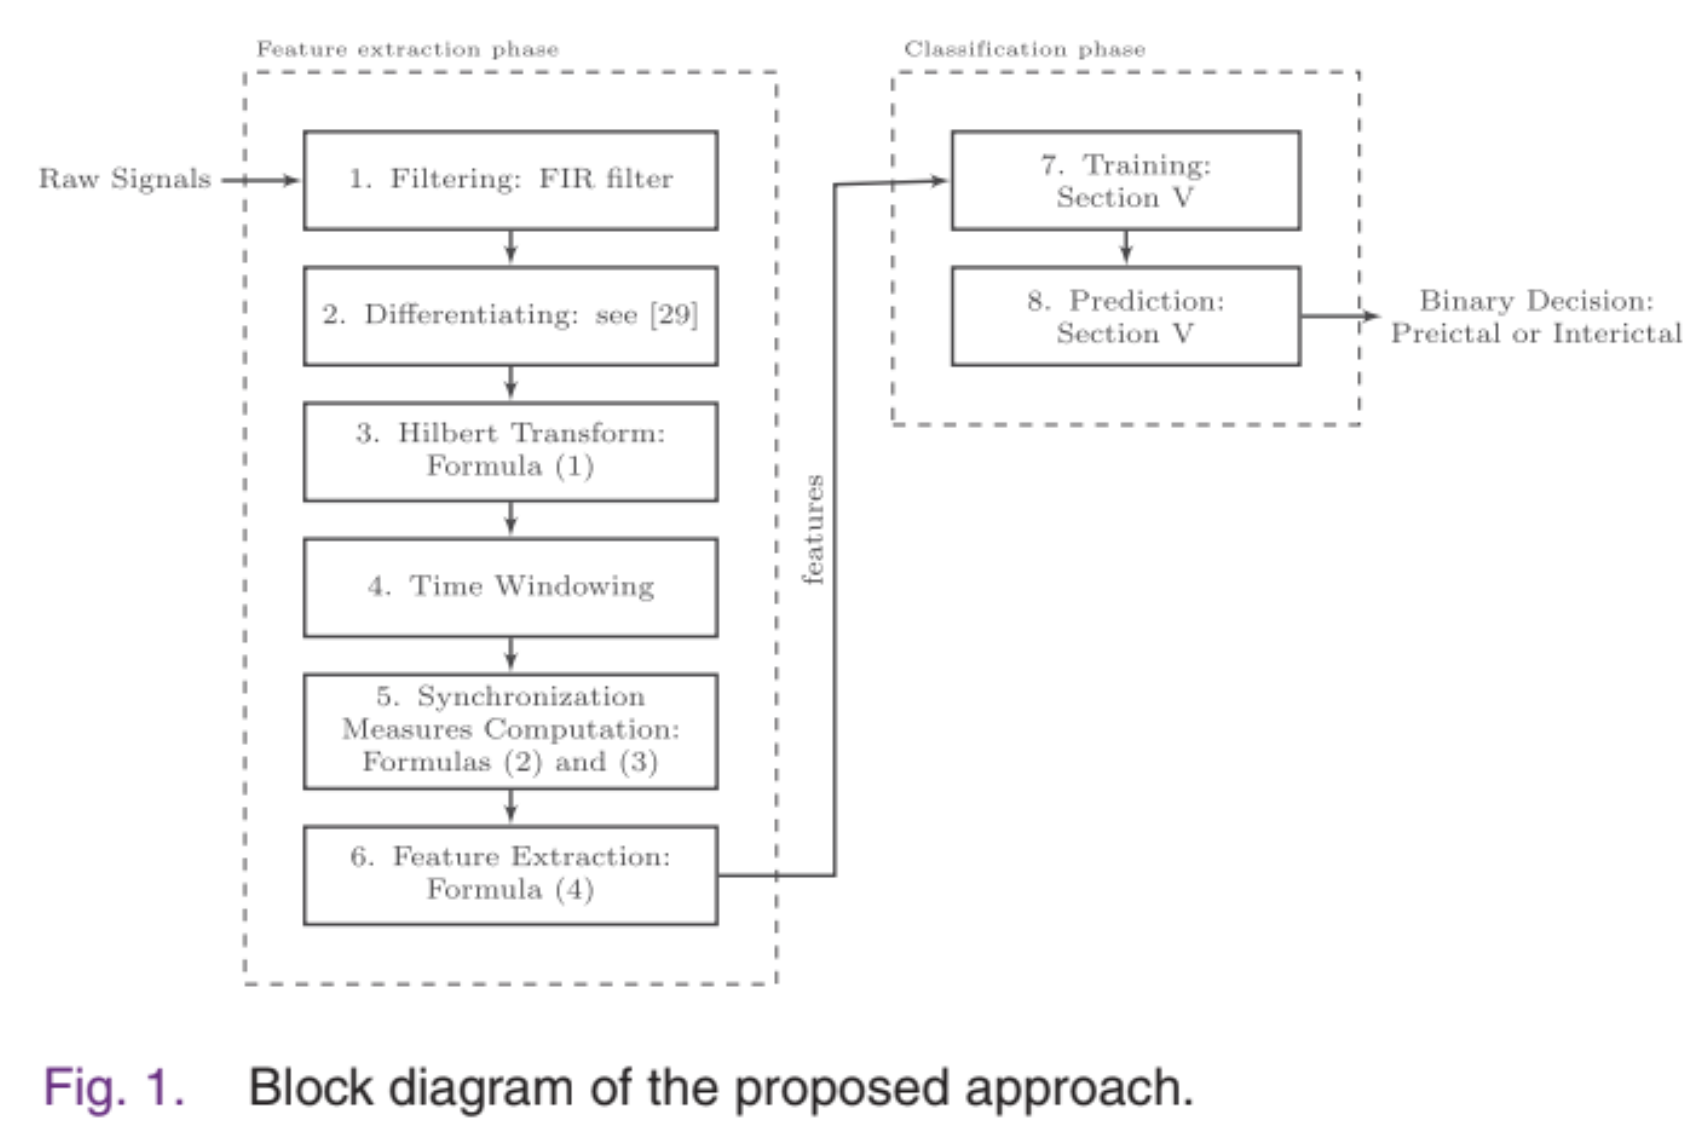


*_Figura 2: Diagrama de flujo del algortimo [8]._*

Tal como se muestra en la Figura 2, el algoritmo *ThALgo* de Detti, et al; (2017) en el cual se basa la propuesta del algoritmo *ModThAlgo* de Detti, et al; (2019), se fundamenta en el procesamiento de señales *raw* de EEG de un paciente, un preprocesamiento de estas señales, una fase de extracción de características y una fase de clasificación.
El funcionamiento de *ModThAlgo* se basa en la aplicación de *ThAlgo* utilizando nuevas reglas de selección en la etapa de extracción de *features* (paso 6), y un nuevo procedimiento de postprocesamiento de las señales.

Esencialmente, ambos algoritmos filtran las señales de EEG en una banda de [8,13] Hz mediante un filtro FIR (paso 1), de forma tal de preservar únicamente las frecuencias de interés. El siguiente paso (paso 2) es la diferenciación de las señales a través del cómputo del módulo de su derivada temporal, con el fin de aplanar el ruido y acentuar los picos de cada señal. Teniendo en cuenta que las regiones donde ocurren más picos acentuados son las más propensas a representar las crisis epiléticas, la diferenciación permite tener una primera idea general acerca de la localización de la crisis epiléptica. Posteriormente, las señales resultantes se transforman a partir de la transformada de Hilbert (paso 3) para el análisis de su fase.

Una vez obtenidas la señales filtradas y diferenciadas, se las segmenta en ventanas temporales consecutivas (con un overlap de 1 segundo y ventanas de 6 segundos) de N puntos cada una (paso 4).
La elección de un tiempo de ventaneo Δt adecuado permite garantizar que las señales dentro de cada ventana puedan aproximarse a condiciones ergódicas y estacionarias, lo que es crucial para realizar análisis significativos sobre la sincronización de las señales. Estas propiedades aseguran que las medidas derivadas de las ventanas sean representativas de las características globales de las señales EEG en esas condiciones específicas.


Estando todas las señales segmentadas con la ventana Δt, es posible calcular medidas de sincronización de fase entre los segmentos de cada par de canales. Esto se logra operando entre las fases de cada canal en cada instante p ∈ [1,N]. Particularmente, el algortimo propuesto utiliza como medida de sincronización de fase a los índices de retraso en fase (PLI) y de retraso en fase ponderado (WPLI), cuyas fórmulas matemáticas se presentan en las ecuaciones (1) y (2), respectivamente. Si bien los registros evidencian que, a medida que se acerca la crisis epilética, ambos indicadores PLI y WPLI tienen una tendencia en aumento, existe, para cada paciente, un par de canales para el cual esta tendencia resulta más evidente. Este par de canales será el que mejor evidencie los focos de crisis epiléticas. Es por esto que, que una vez finalizado el paso de cómputo de PLI y WPLI (paso 5), para la extracción de *features* de cada paciente se selecciona el par de canales que mejor evidencie los focos de crisis epiléticas. Para agilizar el algoritmo, en este trabajo se realizará el preprocesamiento únicamente sobre ese par de canales.


Una vez identificados estos dos canales (ya segmentados con la ventana Δt), se procede al cálculo detallado de los índices de retraso en fase (PLI) y de retraso en fase ponderado (WPLI). Estos índices permiten evaluar el grado de sincronización entre las señales, descartando las contribuciones de ruido o volumen conducido. Las fórmulas correspondientes se aplican a cada ventana de análisis temporal (como se define en las ecuaciones 1 y 2).
En este trabajo no se avanzó más allá del paso 5 ni se realizó la etapa de clasificación, ya que para ello se requiere el uso de Machine Learning.




#### filtrado(diccionario,XX)

Esta función filtra las señales usando un FIR pasabanda entre [8,13] Hz. Esta elección de frecuencia fue tomada con el objetivo de optimizar el análisis de sincronización orientado a la predicción de crisis epilépticas. El rango entre 8-13 Hz corresponde a las ondas alfa, que tienen esa frecuencia característica y están asociadas con estados de relajación y actividad cerebral de bajo nivel.

El filtrado permite reducir el impacto de componentes fuera de la banda de paso que no son relevantes para el análisis, como el ruido de baja frecuencia (por ejemplo, movimientos corporales o artefactos ambientales) y componentes de alta frecuencia (que podrían ser ruido técnico o muscular). Por otro lado, el pasabanda permite enfocarse en patrones relevantes. En pacientes epilépticos, las ondas alfa han demostrado ser significativas para estudiar la transición entre estados preictales e ictales, ya que presentan patrones de sincronización que pueden ser detectados y analizados para predecir crisis epilépticas.

Por último, el filtro permite la optimización de las mediciones de sincronización, ya que éstas resultan más efectivas cuando se aplican a señales filtradas en bandas de frecuencia específicas. Estas mediciones se ven beneficiadas por la eliminación de señales irrelevantes, permitiendo detectar variaciones claras en los niveles de sincronización entre canales EEG en la banda seleccionada.

In [ ]:
#actualiza el diccionario para quedarme solo con la banda de interés (filtrada)

def filtrado(diccionario,XX): #n es el número del paciente expresado en 2 dígitos (XX)
  for i in range(0,len(diccionario[f"PN{XX}"])): #len(diccionario["PNn"]) es la cantidad de listas [raw,raw_nombre] (registros) que tiene la clave de un paciente
    raw_filtrado = diccionario[f"PN{XX}"][i][0].filter(8,13) #pacientes["PNn"][i][0] es el raw del registro i del paciente n
    diccionario[f"PN{XX}"][i][0]=raw_filtrado #sobrescribe el raw original por el raw limitado en frecuencia, el nombre del registro [PNXX][j][1] no se modifica

  return diccionario


#### filtro_derivativo(datos,fs,ganancia)


El filtro derivativo se usa para resaltar cambios abruptos en las señales EEG, como los picos relacionados con eventos preictales e ictales, que ocurren antes y durante las crisis epilépticas.

El cálculo de la derivada toma en cuenta los cambios instantáneos en la amplitud de la señal, mientras que atenua los componentes de bajo cambio, como el ruido de baja frecuencia o las señales constantes. Esta funcion, entonces, cumple un doble proposito, reduciendo el ruido de baja frecuencia y haciendo que las regiones de actividad elevada sean más prominentes. Esto mejora la capacidad de los índices de sincronización para detectar patrones relevantes.


In [ ]:
def filtro_derivativo(datos, fs, ganancia=0.1):
    import numpy as np
    n=len(datos) #longitud de los datos
    datos_filt=np.zeros(n) #crea un array de ceros

    for i in range(0,n):
        filtrados=0
        #valores a distancia 1
        if i>=1:
            filtrados-=2*datos[i-1]
        if i<n-1: #si i+1 no está fuera de rango
            filtrados+=2*datos[i+1]
        #valores a distancia 2
        if i>=2: #si i-2 no está fuera de rango
            filtrados-=datos[i-2]
        if i<n-2: #si i+2 no está fuera de rango
            filtrados+=datos[i+2]
        #aplica la ganancia
        datos_filt[i]=(filtrados*fs)/ganancia

    return datos_filt #array con los datos filtrados de un único canal

####derivada(datos,w,fs)

Para lograr un realce de las caracterísitcas de las convulciones utilizamos la siguiente función que normaliza los datos obtenidos de la filtración derivativa, utilizando la constante de normalización w (Majumdar, Vardhan; 2011).

In [ ]:
def derivada(datos,w,fs):
  datos_der=np.exp((1/w)*np.abs(filtro_derivativo(datos,fs)))

  return datos_der

####datos_diff(diccionario,XX,w)

Esta función ingresa al diccionario, extrae los datos de los archivos raw que contiene y genera un numpy.array con las fases de los canales de interés. Para extraer estas fases, se derivan los datos mediante la función derivada(datos,w,fs), se calcula su transformada de Hilbert, y a partir de su parte real e imaginaria se calcula la fase de los canales. Estos datos de fase se almacenan en un array (datos_registros_fase) con el mismo formato que los datos del raw. De esta forma, los datos de los raw cargados en el diccionario podrán ser sustituídos con los datos de fase para luego calcular medidas de sincronización entre canales.

In [ ]:
def datos_diff(diccionario,XX,w): #w es una constante de normalización del [29] del paper [20] (ThAlgo)
  import mne
  import numpy as np
  from scipy.signal import hilbert
  datos_registros_fase=[]
  for i in range(0,len(diccionario[f"PN{XX}"])): #para cada registro i
    fs=diccionario[f"PN{XX}"][i][0].info["sfreq"]
    datos_reg_fase=[]
    raw=diccionario[f"PN{XX}"][i][0] #el raw del registro i
    datos_reg=raw.get_data() #extrae los datos  de todos los canales (arrays de n canales x m datos) del registro i
    for canal in range(datos_reg.shape[0]): #para cada canal del registro i
      datos_Ch=datos_reg[canal] #datos del canal (lista)
      datos_Ch=derivada(datos_Ch,w,fs) #normaliza y deriva como en [29] del paper [20]
      datos_Ch_hil=hilbert(datos_Ch)
      datos_Ch_fase=np.arctan(np.imag(datos_Ch_hil)/np.real(datos_Ch_hil))
      datos_reg_fase.append(datos_Ch_fase) #datos en fase
    datos_reg_fase=np.array(datos_reg_fase)
    datos_registros_fase.append(datos_reg_fase) #carga el array (lista con listas para cada canal) en la lista de fases

  return datos_registros_fase #devuelve listas donde cada elemento es un array de los datos derivados de un registro y otra donde cada elemento es un array de las fases de los datos

#### ventaneo(diccionario,duracion,solapamiento,XX)

Este código ventanea los raw del diccionario en segmentos de igual duración (duracion) y número de muestras (N), solapados (solapamiento) segundos. El diccionario que retorna tendrá todos los puntos del raw ubicados en ventanas temporales. La función además devuelve la cantidad de puntos por ventana (N), necesaria para hacer los cálculos de los índices PLI y WPLI.

In [ ]:
def ventaneo(diccionario,duracion,solapamiento,XX): #n numero de paciente en 2 dígitos
  diccionario_epoch={}
  for i in range(0,len(diccionario[f"PN{XX}"])): #para cada una de las listas [raw,nombre_raw]
    fs=diccionario[f"PN{XX}"][i][0].info["sfreq"]
    registro=diccionario[f"PN{XX}"][i][1]
    N=fs*duracion
    canales=diccionario[f"PN{XX}"][i][2]
    diccionario[f"PN{XX}"][i][0].set_meas_date(None) #con esta linea se quitan las fechas para que no tire error cuando se arma el epoch
    mne.io.anonymize_info(diccionario[f"PN{XX}"][i][0].info)
    raw=diccionario[f"PN{XX}"][i][0]
    epoch=mne.make_fixed_length_epochs(raw,duracion,overlap) #se ventanea per se de cada registro raw
    diccionario_epoch.setdefault(f"PN{XX}",[]).append([epoch,registro,canales])

  return diccionario_epoch,N #diccionario igual que el de PNnum con canales pero ventaneado

### **Features:**

#### **PLI:**

El PLI (Phase Lag Index) es una métrica utilizada para analizar la conectividad funcional en señales cerebrales como el EEG. Evalúa la sincronización entre dos señales midiendo los desfasajes (lags) en sus fases, con el objetivo de identificar interacciones direccionales y minimizar el efecto de la conectividad espuria debido al volumen conductor.

Para empezar, las señales de EEG son transformadas en el dominio del tiempo-frecuencia usando herramientas como la Transformada de Hilbert.
Esto permite obtener la fase instantánea de cada señal en cada instante de tiempo.
Luego se calcula la diferencia de fase (Δϕ) entre dos señales x(t) e y(t) para cada instante de tiempo para identificar asimetrías en el desfasaje.
El PLI mide la asimetría en la distribución de Δϕ(t) con respecto a 0, ignorando diferencias de fase cercanas a ±π que son consideradas ruido.

Si el desfasaje es consistentemente positivo o negativo (sin cambiar de signo), el PLI tendrá un valor cercano a 1, indicando una conexión funcional robusta y direccional.
Si la distribución de desfasajes es simétrica alrededor de 0, el PLI será cercano a 0, indicando una falta de sincronización funcional entre las señales.

Algunas ventajas del PLI son su robustez frente al volumen conductor, asi como su direccionalidad, que permite identificar conexiones direccionales, algo útil en el estudio de dinámicas cerebrales. Una de sus limitaciones es su sensibilidad ante el ruido ya que, aunque es robusto frente a algunas fuentes de artefactos, el ruido de alta frecuencia o las discontinuidades en las señales pueden afectar su cálculo.


#### **WPLI:**

El Weighted Phase Lag Index (WPLI) es una medida de sincronización entre dos señales EEG que evalúa la coherencia en los desfasajes de sus fases a lo largo del tiempo, teniendo en cuenta principalmente los que no son cercanos a cero. A diferencia del Phase Lag Index (PLI), que solo evalúa la dirección del desfasaje (positiva o negativa), el WPLI incorpora un peso que amplifica las contribuciones significativas (desfasajes con mayor magnitud). Esto lo hace más robusto frente a artefactos.

En el análisis de EEG para predicción de crisis epilépticas, el WPLI permite identificar patrones de sincronización entre diferentes regiones del cerebro. Estos patrones pueden reflejar procesos neuronales relacionados con la propagación de actividad ictal, siendo indicadores útiles en la predicción temprana de crisis.


#### PLI(diccionario_vent_2chan,XX,N):

Esta función ingresa a cada ventana del diccionario cargado con epochs y extrae las fases de los canales seleccionados. Genera la operación matemática necesaria para calcular eL PLI (ver ecuación 1) y guarda el valor adoptado en cada ventana en un diccionario (diccionario_PLI) con el mismo formato que los generados anteriormente.

$PLI_{h,k,Δt}=\frac{1}{N}\sum_{1}^{N} sign(\Phi_h(p)-\Phi_k(p))$   &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; (ecuación 1)



In [ ]:
def PLI(diccionario_vent_2chan,XX,N):
    """
    - fases: ndarray de fases (en radianes) de forma (n_canales, n_puntos)
    - N: longitud del segmento en número de muestras
    - pli: el valor de Phase Lag Index (PLI) entre los dos canales.
    """
    diccionario_PLI={}
    for i in range(0,len(diccionario_vent_2chan[f"PN{XX}"])): #para cada registro
      registro=diccionario_vent_2chan[f"PN{XX}"][i][1]
      PLIs_vent=[] #PLIs del registro (array con un PLI por ventana)
      for j in range(0,len(diccionario_vent_2chan[f"PN{XX}"][i][0])): #para cada ventana del registro ventaneado
        PLI=0
        epoch=diccionario_vent_2chan[f"PN{XX}"][i][0][j]
        fases=epoch.get_data() #numpy array: lista con listas (tiene los datos sobrescritos con fases) para cada canal
        #con el primer [0] entra al ndarray
        fase_h = fases[0][0] #fases del primer canal
        fase_k = fases[0][1] #fases del segundo canal
        for u in range(0,len(fase_h)): #para cada dato de fase (para cada punto)
          sign_fase_dif = np.sign((fase_h[u] - fase_k[u]))
          PLI+=sign_fase_dif
        PLI/=N
        PLI=np.abs(PLI)
        PLIs_vent.append(PLI)

      diccionario_PLI.setdefault(f"PN{XX}",[]).append([PLIs_vent,registro]) #diccionario con tantas listas como registros donde cada lista contiene en la posicion 0 una lista con una lista de los PLI

    return diccionario_PLI


#### WPLI(diccionario_vent_2chan,XX,N)

Esta función ingresa a cada ventana del diccionario cargado con epochs y extrae las fases de los canales seleccionados. Genera la operación matemática necesaria para calcular eL WPLI (ver ecuación 2) y guarda el valor adoptado en cada ventana en un diccionario (diccionario_WPLI) con el mismo formato que los generados anteriormente.

$WPLI_{h,k,Δt}=\frac{|\frac{1}{N}\sum_{1}^{N} sin(\Phi_h(p)-\Phi_k(p))|}{\frac{1}{N}\sum_{1}^{N} |sin(\Phi_h(p)-\Phi_k(p))|}$   &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; (ecuación 2)

In [ ]:
def WPLI(diccionario_vent_2chan,XX,N):
  diccionario_WPLI={}
  for i in range(0,len(diccionario_vent_2chan[f"PN{XX}"])): #para cada registro
    registro=diccionario_vent_2chan[f"PN{XX}"][i][1]
    WPLIs_vent=[] #WPLIs del registro (array con un WPLI por ventana)
    for j in range(0,len(diccionario_vent_2chan[f"PN{XX}"][i][0])): #para cada ventana del registro ventaneado
      WPLI_num=0
      WPLI_den=0
      WPLI=0
      epoch=diccionario_vent_2chan[f"PN{XX}"][i][0][j]
      fases=epoch.get_data() #numpy array: lista con listas (tiene los datos sobrescritos con fases) para cada canal
      #con el primer [0] entra al ndarray
      fase_h = fases[0][0] #fases del primer canal
      fase_k = fases[0][1] #fases del segundo canal
      for u in range(0,len(fase_h)): #para cada dato de fase (para cada punto de los N puntos)
        sin_fase_dif = np.sin((fase_h[u] - fase_k[u]))
        WPLI_num+=sin_fase_dif
        WPLI_den+=np.abs(sin_fase_dif)
      WPLI_num/=N
      WPLI_num=np.abs(WPLI_num)
      WPLI_den/=N
      WPLI=WPLI_num/WPLI_den
      WPLIs_vent.append(WPLI)

    diccionario_WPLI.setdefault(f"PN{XX}",[]).append([WPLIs_vent,registro]) #diccionario con tantas listas como registros donde cada lista contiene en la posicion 0 una lista con una lista de los WPLI

  return diccionario_WPLI



####Algoritmo *ThAlgo*

Para la elaboración de un algoritmo de clasificación que funcione correctamente, es necesario elaborar los features extraídos directamente de la información del EEG, como por ejemplo las medidas de sincronización junto con información adicional obtenida a partir de ellas. Por su parte, estos features deberían ser capaces de informar al clasificador, en cada instante de tiempo, sobre la relación que existe entre su valor actual y sus valores pasados, de forma tal de poder detectar una tendencia creciente en la sincronización de los canales.

Para el presente trabajo se consideró que un fragmento de EEG es preictal si el mismo pertenece a los 300 segundos previos al inicio de una crisis epiléptica. Para que suceda una detección correcta de un estado preictal en estas condiciones, es útil definir funciones que sean capaces de resaltar las tendencias crecientes en las medidas de sincronización. Detti, et al. (2017) propone indicadores, basados en la media móvil. Para su cómputo, desarrollan las siguientes funciones:
$$ T_{h,k}(\Delta t) $$
$$ L_{h,k}(\Delta t) $$
$$ M_{h,k}(\Delta t) $$

Donde la función T describe la tendencia de las mediciones obtenidas del PLI y WPLI, es decir describe el aumento o disminución de la sincronización de las señales, ponderándolas exponencialmente a lo largo del tiempo. De esta forma, el valor actual de los índices de una ventana se comparan con los valores de los índices correspondientes a las ventanas anteriores, adoptando la relación entre ventanas más alejadas un menor peso que la correspondiente a ventanas más cercanas.

La función L representa un límite inferior dentro de una ventana de tiempo reciente, y permite delimitar la tendencia para saber si un cambio es significativo. Esto ayuda a definir un umbral mínimo de la tendencia, por debajo del cual el cambio no se considera relevante.

Por último, M mide la elevación de la tendencia, es decir, por cuánto la tendencia de la ventana actual supera al límite inferior en un intervalo de tiempo.

In [ ]:
def calcular_tendencia(indices,w=7): #calcula la función de tendencia T_{h,k} de cada ventana como un promedio móvil exponencial (EMA)
    """
    indices: lista con los PLI/WPLI de cada ventana
    w: factor de suavizado
    T: lista con los valores de tendencia
    """
    T=[indices[0]]  #inicia con el primer valor de PLI/WPLI
    alpha=2/(w+1)
    for t in range(1,len(indices)):
        T.append(alpha*indices[t]+(1-alpha)*T[-1])

    return T


def calcular_limite_inferior(tendencia,p=27): #calcula el límite inferior actual L_{h,k} para cada ventana como el mínimo de una serie de ventanas anteriores
    """
    tendencia: valores de tendencia (T)
    p: longitud de la ventana para calcular el mínimo
    L: lista con los valores de límite inferior
    """
    L=[]
    for t in range(len(tendencia)):
        inicio=max(0,t-p+1)
        L.append(min(tendencia[inicio:t+1]))

    return L


def calcular_elevacion(tendencia, elevacion): #calcula la función de elevación M_{h,k} para cada ventana
    """
    tendencia: lista con los valores de tendencia.
    elevacion: lista con los valores de límite inferior.
    [T - L for T, L in zip(tendencia, elevacion)]: lista con los valores de elevación.
    """

    return [T-L for T, L in zip(tendencia, elevacion)]


def calcular_maacd(indices, w=7, p=27): #calcula el MAACD (M) para cada ventana.
    T=calcular_tendencia(indices,w)
    L=calcular_limite_inferior(T,p)
    M=calcular_elevacion(T,L)

    return M

def thalgo(lista_pli,lista_wpli,umbral=0.1,w=7,p=27): #calcula el MAACD (M) y un MAACD combinado para las lista de PLI y WPLI
    M_pli=calcular_maacd(lista_pli,w,p)
    M_wpli=calcular_maacd(lista_wpli,w,p)

    return M_pli,M_wpli


####features_etiquetas(epochs,N,dicc_PLI,dicc_WPLI,fs,duracion,solapamiento,inicio_conv,fin_conv,XX,test,train)



Los features extraídos en el presente trabajo fueron tanto en el dominio frecuencial como en el temporal.


* **Features del dominio temporal:**
Se computaron 9 características estadísticas, a saber: media, varianza, desvío estándar, curtosis, asimetría, energía, potencia, rango pico a pico y cruces por cero. Estos features permiten describir la morfología de la señal en términos de su distribución y variabilidad. La varianza y el desvío estándar pueden reflejar la inestabilidad de las señal antes de una crisis, mientras que la energía y potencia pueden indicar cambios en la actividad asociadaos a la transición entre estados.

* **Features del dominio frecuencial:**
Para el análisis en frecuencia, se extrajeron características tanto de la señal en su totalidad como de 6 bandas de frecuencia distintas correspondientes a los ritmos cerebrales. La extracción de estos features se realizó a través del cómputo de la densidad de potencia espectral (PSD) mediante el método de estimación de Welch. Para la señal completa se calculó el centroide espectral y la frecuencia dominante, mientras que para cada banda de frecuencia se calcularon 6 medidas estadísticas (media, desvío estandar, máximo, mínimo, rango pico a pico y potencia). Estos features permiten evaluar la distribución de energía en distintas bandas de frecuencia, lo cual es clave en la clasificación ictal/preictal, ya que un incremento en potencia puede indicar el comienzo de una crisis. Así, los cambios en el centroide espectral y la frecuencia dominante pueden ser indicadores tempranos de actividad.

* **Features de sincronización:** Se extrajeron 4 features adicionales, correspondientes a los índices de sincronización PLI y WPLI, y al MAACD (Amplitud Convergente/Divergente del Promedio Móvil) calculado sobre cada uno de ellos. Estos features permiten evauluar las tendencias de sincronización entre señales. La alteración de los patrones de sincronización es un fenómeno indicativo de la transición preictal-ictal. El PLI y el WPLI proporcionan información sobre los cambios en la fase relativa entre señales, mientras que el MAACD permite analizar variaciones en la estabilidad de estos índices a lo largo del tiempo.

* **Features de procesamiento avanzado:** Para finalizar la caracterización de las señales, se extrajeron 5 medidas estadísticas (media, desvío estándar, máximo, mínimo y rango pico a pico) de la transformada de Wavelet discreta de 4 niveles. Esta transformada permite obtener 4 detalles y una aproximación, por lo que mediante este método se extrajeron un total de 25 features. Estos features permiten capturar información sobre la dinámica temporal y frecuencial de la señal con una mayor resolución. Como las crísis suelen presentar cambios abruptos en la actividad neuronal, la decomposición wavelet puede ser útil para detectar transiciones súbitas entre estados preictales e ictales. En particular, los coeficientes de wavelet pueden reflejar patrones transitorios que no son evidentes en los análisis tradicionales de tiempo o frecuencia, lo que mejora la capacidad del modelo para anticipar una crisis.

El algoritmo desarrollado por Detti, et al. (2019) utiliza ventanas de 6 segundos para la extracción de los índices PLI, WPLI y MAACD. Por esta razón, para la extracción de features en este trabajo se utilizaron ventanas de 6 segundos solapadas 1 segundo. De esta forma, cada ventana tendrá un feature de cada tipo, incluídos los 4 correspondientes a los índices de sincronización.

In [ ]:
import scipy.fftpack as fft
def features_etiquetas(epochs,N,dicc_PLI,dicc_WPLI,fs,duracion,solapamiento,inicio_conv,fin_conv,XX,test,train):
    from scipy.stats import entropy, skew, kurtosis
    diccionario_features_etiquetas={}
    diccionario_features={}
    for i in range(len(epochs[f"PN{XX}"])): #para cada registro ventaneado
      features=[]
      features_test=[]
      etiquetas=[]
      for j in range(len(epochs[f"PN{XX}"][i][0])): #para cada ventana del registro ventaneado
        features_ventana=[] #se carga con los features de la ventana actual
        for canal in range(len(epochs[f"PN{XX}"][i][0].info["ch_names"])): #se extraen los features de la ventana para cada canal
          ventana=epochs[f"PN{XX}"][i][0][j]
          ventana=ventana.get_data()[0][canal]

          #FEATURES DEL PAPER: PLI, WPLI y MAACD (4 features)
          M_PLI,M_WPLI=thalgo(dicc_PLI[f"PN{XX}"][i][0],dicc_WPLI[f"PN{XX}"][i][0]) #se calculan los Moving Average and Amplitude Convergence/Divergence (MAACD) para cada ventana
          features_ventana.extend([
            dicc_PLI[f"PN{XX}"][i][0][j],
            dicc_WPLI[f"PN{XX}"][i][0][j],
            M_PLI[j],
            M_WPLI[j]
          ])

          #FEATURES ADICIONALES
          #wavelet (5 features)
          wavelet='db4'
          nivel=4
          coeffs=pywt.wavedec(ventana,wavelet,level=nivel) #se computa la transformada de Wavelet
          for coeff in coeffs:
            features_ventana.extend([np.mean(coeff),np.std(coeff),np.max(coeff),np.min(coeff),np.ptp(coeff)])

          #features en el dominio temporal (9 features)
          features_ventana.extend([
            np.mean(ventana), #media
            np.var(ventana), #varianza
            np.std(ventana), #desvio estandar
            stats.kurtosis(ventana), #curtosis
            stats.skew(ventana), #asimetría
            np.sum(np.square(ventana)), #energía
            np.mean(np.square(ventana)), #potencia
            np.ptp(ventana), #rango pico a pico
            np.sum(np.diff(np.sign(ventana))!=0)/len(ventana)  #cruces por cero
          ])

          #features en el dominio frecuencial (2 features)
          f,Pxx=signal.welch(ventana,fs,nperseg=fs//2) #PSD con Welch
          centroide_frec=np.sum(f*Pxx)/np.sum(Pxx) #centroide espectral
          f_max=f[np.argmax(Pxx)] #frecuencia dominante
          features_ventana.extend([centroide_frec,f_max])

          #features por banda de frecuencia (6 features x 6 bandas --> 36 features)
          potencias_bandas={}
          bandas_frecuencia={'delta':(0.5,4),'theta':(4,8),'alfa':(8,13),'beta':(13,30),'gamma':(30,40),"gamma alto":(40,100)}
          for banda, (bajo,alto) in bandas_frecuencia.items():
            mascara=(f>=bajo) & (f<=alto)
            Pxx_banda=Pxx[mascara]
            potencias_bandas[banda]=np.sum(Pxx_banda)
            features_ventana.extend([
              np.mean(Pxx_banda),
              np.std(Pxx_banda),
              np.max(Pxx_banda),
              np.min(Pxx_banda),
              np.ptp(Pxx_banda),
              potencias_bandas[banda]
              ])

      #carga de features y etiquetados según registro

        if epochs[f"PN{XX}"][i][1] in train: #si el registro es de entrenamiento
          features.append(features_ventana)
          #etiquetado de ventanas (preictal=1,interictal=0). Intervalo de predicción: 300s
          desplazamiento=N*(1-solapamiento/duracion) #desplazamiento por ventana
          inicio=j*desplazamiento #punto de inicio de la ventana
          final=inicio+N-1 #punto final de la ventana
          if final<inicio_conv-300*fs:
              etiquetas.append(0) #interictal
          elif inicio>=inicio_conv-300*fs and final<=inicio_conv: #dentro del intervalo de predicción
              etiquetas.append(1) #preictal
          else:
              etiquetas.append(0) #interictal

        elif epochs[f"PN{XX}"][i][1] in test: #si el registro es de testeo
          features_test.append(features_ventana)

      if epochs[f"PN{XX}"][i][1] in train:
        features=np.array(features)
        etiquetas=np.array(etiquetas)
        diccionario_features_etiquetas.setdefault(f"PN{XX}",[]).append([features,etiquetas,j+1])

      if epochs[f"PN{XX}"][i][1] in test: #si el registro es de testeo
        features_test=np.array(features_test)
        diccionario_features.setdefault(f"PN{XX}",[]).append([features_test,epochs[f"PN{XX}"][i][1],j+1])

    return diccionario_features_etiquetas,diccionario_features #contiene los features de cada canal para todos los registros y las etiquetas de los registros de entrenamiento

##Datos Pacientes

###PN00

#### PN00-1

* Registration start time: 19.39.33

* Registration end time:  20.22.58

* Seizure start time: 19.58.36

* Seizure end time: 19.59.46




In [ ]:
inicio_0_1=segundos(19,58,36)-segundos(19,39,33)
final_0_1=segundos(19,59,46)-segundos(19,39,33)
intervalo_0_1=segundos(20,22,58)-segundos(19,59,46)
print("inicio:",inicio_0_1,"s")
print("final:",final_0_1,"s")
print("intervalo:",intervalo_0_1)

inicio: 1143 s
final: 1213 s
intervalo: 1392


#### PN00-2

* Registration start time:  02.18.17

* Registration end time:  02.56.19

* Seizure start time: 02.38.37

* Seizure end time: 02.39.31

In [ ]:
inicio_0_2=segundos(2,38,37)-segundos(2,18,17)
final_0_2=segundos(2,39,31)-segundos(2,18,17)
intervalo_0_2=segundos(2,56,19)-segundos(2,39,31)
print("inicio:",inicio_0_2,"s")
print("final:",final_0_2,"s")
print("intervalo:",intervalo_0_2)

inicio: 1220 s
final: 1274 s
intervalo: 1008


####PN00-3

* Registration start time: 18.15.44

* Registration end time: 18.57.13

* Seizure start time: 18.28.29

* Seizure end time: 19.29.29

In [ ]:
inicio_0_3=segundos(18,28,29)-segundos(18,15,44)
final_0_3=segundos(18,57,13)-segundos(18,15,44)
intervalo_0_3=segundos(18,57,13)-segundos(18,57,13)
print("inicio:",inicio_0_3,"s")
print("final:",final_0_3,"s")
print("intervalo:",intervalo_0_3)

inicio: 765 s
final: 2489 s
intervalo: 0


####PN00-4
* Registration start time: 20.51.43
* Registration end time: 21.26.25
* Seizure start time: 21.08.29
* Seizure end time: 21.09.43

In [ ]:
inicio_0_4=segundos(21,8,29)-segundos(20,51,43)
final_0_4=segundos(21,9,43)-segundos(20,51,43)
intervalo_0_4=segundos(21,26,25)-segundos(21,9,43)
print("inicio:",inicio_0_4,"s")
print("final:",final_0_4,"s")
print("intervalo:",intervalo_0_4)

inicio: 1006 s
final: 1080 s
intervalo: 1002


####PN00-5
* Registration start time: 22.22.04
* Registration end time:  22.57.27
* Seizure start time: 22.37.08
* Seizure end time: 22.38.15

In [ ]:
inicio_0_5=segundos(22,37,8)-segundos(22,22,4)
final_0_5=segundos(22,38,15)-segundos(22,22,4)
intervalo_0_5=segundos(22,57,27)-segundos(22,38,15)
print("inicio:",inicio_0_5,"s")
print("final:",final_0_5,"s")
print("intervalo:",intervalo_0_5)

inicio: 904 s
final: 971 s
intervalo: 1152



### PN03









####PN03-1
* Registration start time:22.44.37

* Registration end time: 11.41.34

* Seizure start time:09.29.10

* Seizure end time: 09.31.01

In [ ]:
inicio_3_1=segundos(9,29,10)+segundos(24,0,0)-segundos(22,44,37)
final_3_1=segundos(9,31,1)+segundos(24,0,0)-segundos(22,44,37)
intervalo_3_1=segundos(11,41,34)-segundos(9,31,1)
print("inicio:",inicio_3_1,"s")
print("final:",final_3_1,"s")
print("intervalo:",intervalo_3_1)

inicio: 38673 s
final: 38784 s
intervalo: 7833


####PN03-2
* Registration start time: 21.31.04
* Registration end time: 08.47.04
* Seizure start time:07.13.05
* Seizure end time: 07.15.18

In [ ]:
inicio_3_2=segundos(7,13,5)+segundos(24,0,0)-segundos(21,31,4)
final_3_2=segundos(7,15,18)+segundos(24,0,0)-segundos(21,31,4)
intervalo_3_2=segundos(8,47,4)-segundos(7,13,18)
print("inicio:",inicio_3_2,"s")
print("final:",final_3_2,"s")
print("intervalo:",intervalo_3_2)

inicio: 34921 s
final: 35054 s
intervalo: 5626


###PN05

####PN05-2
* Registration start time: 06.46.02
* Registration end time: 09.19.47
* Seizure start time: 08.45.25
* Seizure end time: 08.46.00


In [ ]:
inicio_5_2=segundos(8,45,25)-segundos(6,46,2)
final_5_2=segundos(8,46,0)-segundos(6,46,2)
intervalo_5_2=segundos(9,19,47)-segundos(8,46,0)
print("inicio:",inicio_5_2,"s")
print("final:",final_5_2,"s")
print("intervalo:",intervalo_5_2)

inicio: 7163 s
final: 7198 s
intervalo: 2027


####PN05-3
* Registration start time:06.01.23
* Registration end time: 08.06.57
* Seizure start time:07.55.19
* Seizure end time: 07.55.49


In [ ]:
inicio_5_3=segundos(7,55,19)-segundos(6,1,23)
final_5_3=segundos(7,55,49)-segundos(6,1,23)
intervalo_5_3=segundos(8,6,57)-segundos(7,55,49)
print("inicio:",inicio_5_3,"s")
print("final:",final_5_3,"s")
print("intervalo:",intervalo_5_3)

inicio: 6836 s
final: 6866 s
intervalo: 668


####PN05-4

* Registration start time: 06.38.35
* Registration end time: 08.00.23
* Seizure start time: 07.38.43
* Seizure end time: 07.39.22

In [ ]:
inicio_5_4=segundos(7,38,43)-segundos(6,38,35)
final_5_4=segundos(7,39,22)-segundos(6,38,35)
intervalo_5_4=segundos(8,0,23)-segundos(7,39,22)
print("inicio:",inicio_5_4,"s")
print("final:",final_5_4,"s")
print("intervalo:",intervalo_5_4)

inicio: 3608 s
final: 3647 s
intervalo: 1261


###PN16

#### PN16-1

* Registration start time: 20.45.21

* Registration end time: 23.03.11

* Seizure start time: 22.45.05

* Seizure end time: 22.47.08




In [ ]:
inicio_16_1=segundos(22,45,5)-segundos(20,45,21)
final_16_1=segundos(22,47,8)-segundos(20,45,21)
intervalo_16_1=segundos(23,3,11)-segundos(22,47,8)
print("inicio:",inicio_16_1,"s")
print("final:",final_16_1,"s")
print("intervalo:",intervalo_16_1)

inicio: 7184 s
final: 7307 s
intervalo: 963


####PN16-2
* Registration start time: 00.53.55
* Registration end time: 03.28.52
* Seizure start time: 03.16.49
* Seizure end time:03.18.36

In [ ]:
inicio_16_2=segundos(3,16,49)-segundos(0,53,55)
final_16_2=segundos(3,18,36)-segundos(0,53,55)
intervalo_16_2=segundos(3,28,52)-segundos(3,18,36)
print("inicio:",inicio_16_2,"s")
print("final:",final_16_2,"s")
print("intervalo:",intervalo_16_2)

inicio: 8574 s
final: 8681 s
intervalo: 616


###PN17

#### PN17-1
* Registration start time: 20.14.28

* Registration end time: 22.49.05

* Seizure start time: 22.34.48

* Seizure end time: 22.35.58


In [ ]:
inicio_17_1=segundos(22,34,48)-segundos(20,14,28)
final_17_1=segundos(22,35,58)-segundos(20,14,28)
intervalo_17_1=segundos(22,49,5)-segundos(22,35,58)
print("inicio:",inicio_17_1,"s")
print("final:",final_17_1,"s")
print("intervalo:",intervalo_17_1)

inicio: 8420 s
final: 8490 s
intervalo: 787


####PN17-2
* Registration start time: 13.52.18
* Registration end time: 16.25.10
* Seizure start time: 16.01.09
* Seizure end time: 16.02.32

In [ ]:
inicio_17_2=segundos(16,1,9)-segundos(13,52,18)
final_17_2=segundos(16,2,32)-segundos(13,52,18)
intervalo_17_2=segundos(16,25,10)-segundos(16,2,32)
print("inicio:",inicio_17_2,"s")
print("final:",final_17_2,"s")
print("intervalo:",intervalo_17_2)

inicio: 7731 s
final: 7814 s
intervalo: 1358


### Inicialización de Datos

In [ ]:
mne.set_log_level('ERROR') #para que no haga un print cada vez que filtra
T=300
duracion=6
overlap=1
w=100000

corte=[np.min([inicio_0_1,inicio_0_2,inicio_0_3,inicio_0_4,inicio_0_5,1000]),np.min([inicio_3_1,inicio_3_2,1200]),np.min([inicio_5_2,inicio_5_3,inicio_5_4,1000]),np.min([inicio_16_1,inicio_16_2,1000]),np.min([inicio_17_1,inicio_17_2,1000])]
corte2=[np.min([intervalo_0_1,intervalo_0_2,intervalo_0_4,intervalo_0_5,1200]),np.min([intervalo_3_1,intervalo_3_2,1200]),np.min([intervalo_5_2,intervalo_5_3,intervalo_5_4,1200]),np.min([intervalo_16_1,intervalo_16_2,1200]),np.min([intervalo_17_1,intervalo_17_2,1200])]

NP=[0,3,5,16,17] #numeros de pacientes
CH=[["EEG Fc5","EEG Fc6"],["EEG F4","EEG F8"],["EEG T3","EEG FP2"],["EEG F9","EEG Cp2"],["EEG Fz","EEG F10"]] #canales de pacientes
REGcv=[["PN00-1","PN00-2","PN00-3","PN00-4","PN00-5"],["PN03-1","PN03-2"],["PN05-2","PN05-3","PN05-4"],["PN16-1","PN16-2"],["PN17-1","PN17-2"]] #lista con los registros de las convulsiones utilizadas para cada paciente
CROP=[[[inicio_0_1-corte[0],final_0_1+corte2[0]-1],[inicio_0_2-corte[0],final_0_2+corte2[0]-1],[inicio_0_3-corte[0],final_0_3],[inicio_0_4-corte[0],final_0_4+corte2[0]-1],[inicio_0_5-corte[0],final_0_5+corte2[0]-1]],[[inicio_3_1-corte[1],final_3_1+corte2[1]-1],[inicio_3_2-corte[1],final_3_2+corte2[1]-1]],[[inicio_5_2-corte[2],final_5_2+corte2[2]-1],[inicio_5_3-corte[2],final_5_3+corte2[2]-1],[inicio_5_4-corte[2],final_5_4+corte2[2]-1]],[[inicio_16_1-corte[3],final_16_1+corte2[3]-1],[inicio_16_2-corte[3],final_16_2+corte2[3]-1]],[[inicio_17_1-corte[4],final_17_1+corte2[4]-1],[inicio_17_2-corte[4],final_17_2+corte2[4]-1]]]
START=[[inicio_0_1,inicio_0_2,inicio_0_3,inicio_0_4,inicio_0_5],[inicio_3_1,inicio_3_2],[inicio_5_2,inicio_5_3,inicio_5_4],[inicio_16_1,inicio_16_2],[inicio_17_1,inicio_17_2]]
END=[[final_0_1,final_0_2,final_0_3,final_0_4,final_0_5],[final_3_1,final_3_2],[final_5_2,final_5_3,final_5_4],[final_16_1,final_16_2],[final_17_1,final_17_2]]
test_train=[[["PN00-5.edf","PN00-2.edf","PN00-3.edf","PN00-4.edf"],["PN00-1.edf"]],[["PN03-2.edf"],["PN03-1.edf"]],[["PN05-4.edf","PN05-3.edf"],["PN05-2.edf"]],[["PN16-1.edf"],["PN16-2.edf"]],[["PN17-1.edf"],["PN17-2.edf"]]] #PN03 y PN05 tienen mucha variabilidad entre crisis, es muy dificil entrenar con uno solo

#RESULTADOS

###Selección de Paciente

Como se explicó previamente en Materiales y Métodos, los pacientes con los cuales se trabajará esta sección de resultados son aquellos para los cuales Detti et al; (2019) especificó el par de canales utilizados para el cálculo de los índices PLI y WPLI. Como se detalló en el apartado Algoritmo ModThAlgo de la sección anterior, existe, para cada paciente, un par de canales para el cual la tendencia creciente en los índices de sincronización resulta más evidente. Este par de canales será el que mejor evidencie los focos de crisis epiléticas, y es sobre el cual se trabaja en este informe (especificado por Detti, et al; (2019)).

In [ ]:
#SELECCIÓN DEL PACIENTE A PROCESAR
print("ELIJA UN NÚMERO DE PACIENTE DE LA LISTA\n")
print("Pacientes disponibles:")

for i in range(0,len(NP)):
  print(f"\t\t\t{NP[i]}")

n=int(input("Su selección: "))

ELIJA UN NÚMERO DE PACIENTE DE LA LISTA

Pacientes disponibles:
			0
			3
			5
			16
			17
Su selección: 0


##Obtención de Índices de Sincronización

###Carga y Filtrado

Se cargan los registros de EEG del paciente seleccionado de acuerdo a los parámetros obtenidos para ese paciente por la función Buscar_PN(n). Luego, se aplica un primer filtrado que limita la banda de frecuencia de los datos entre 8 y 13 Hz, de acuerdo a lo realizado por Detti, et al; (2019).


Registro PN00-1.edf



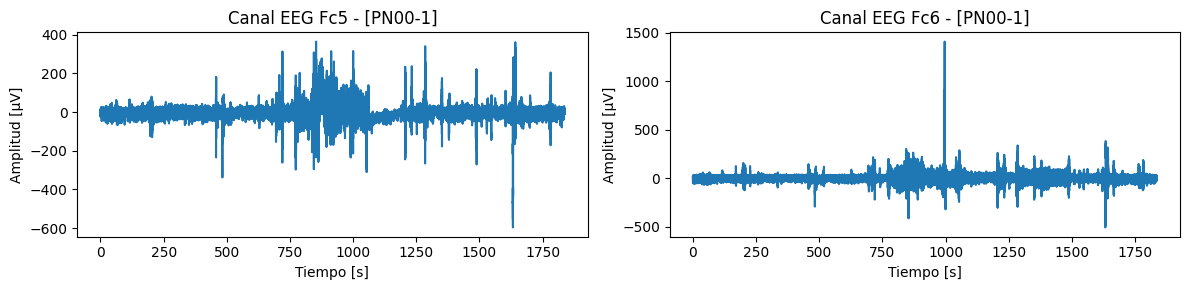

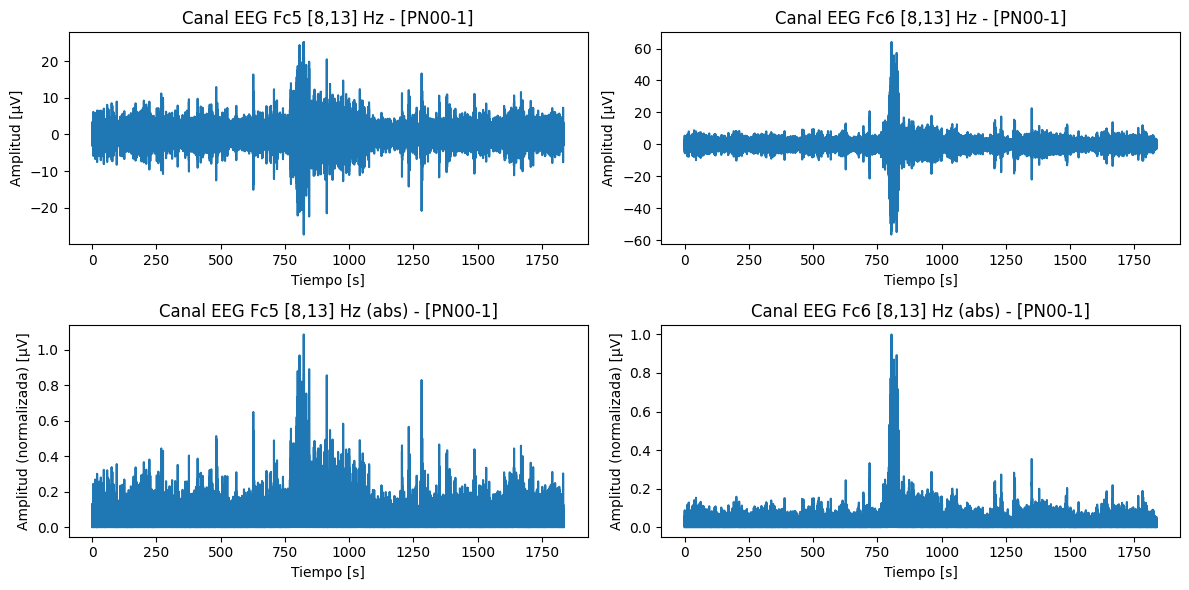


Registro PN00-2.edf



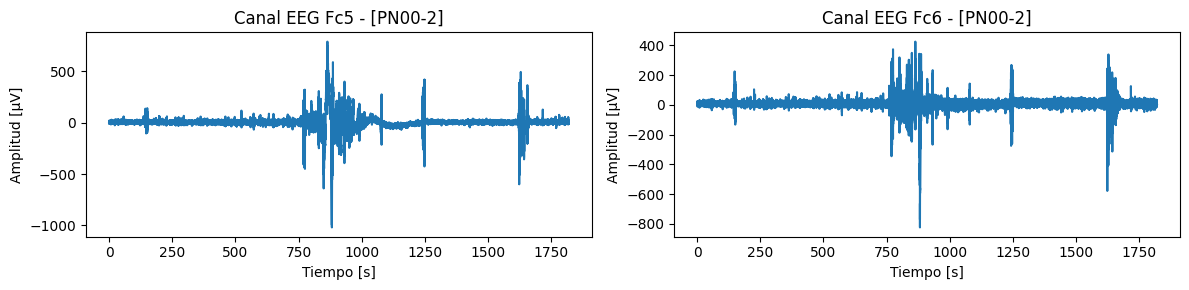

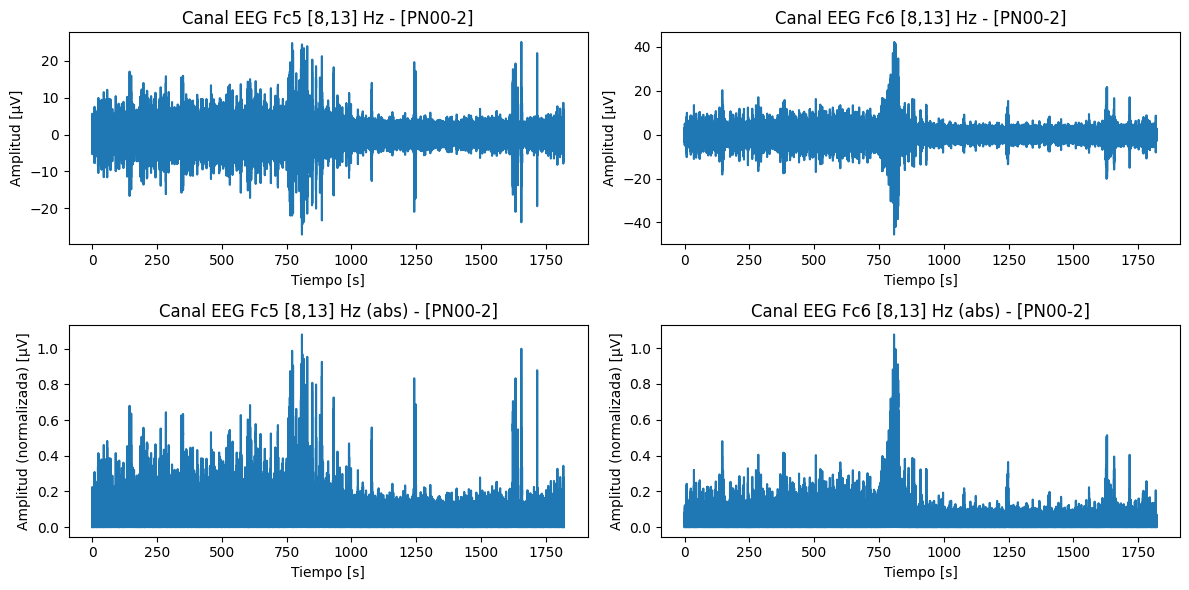


Registro PN00-3.edf



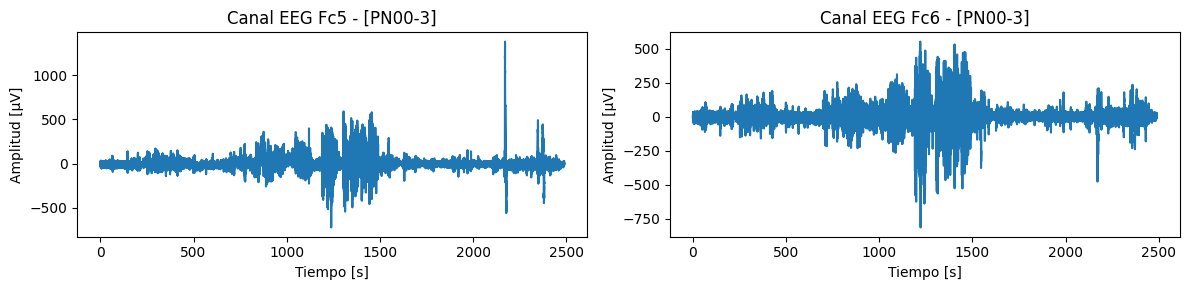

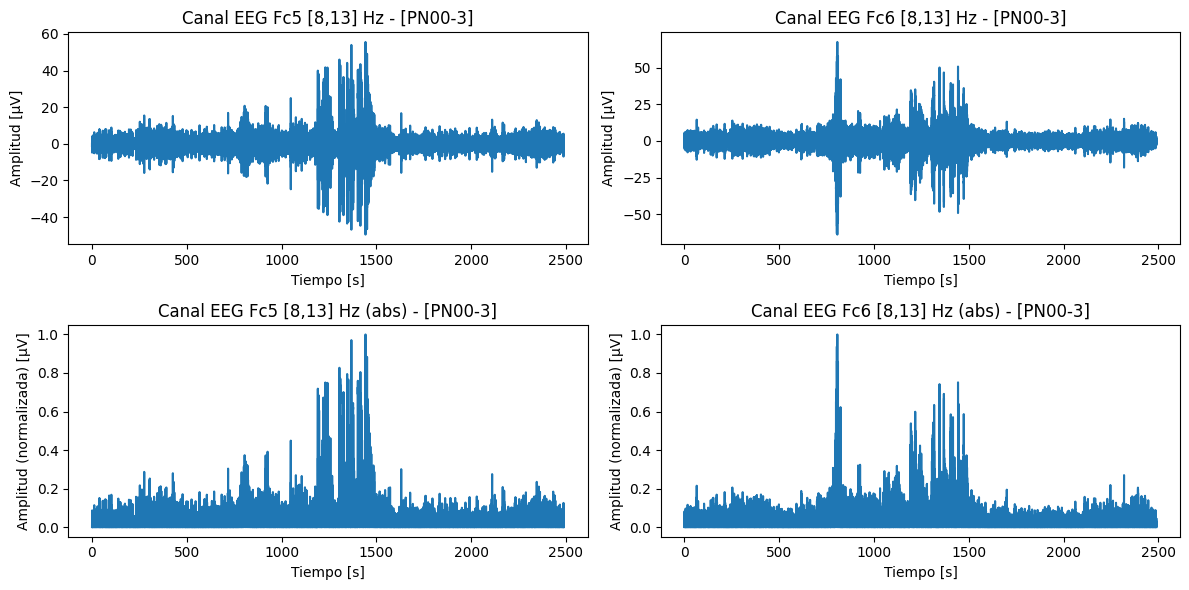


Registro PN00-4.edf



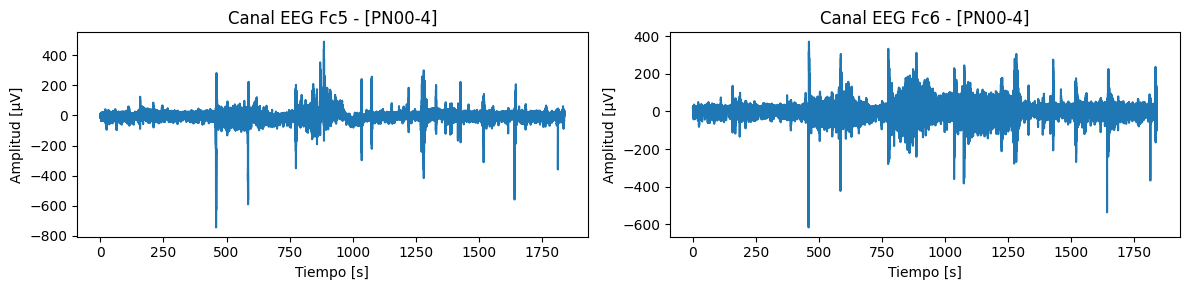

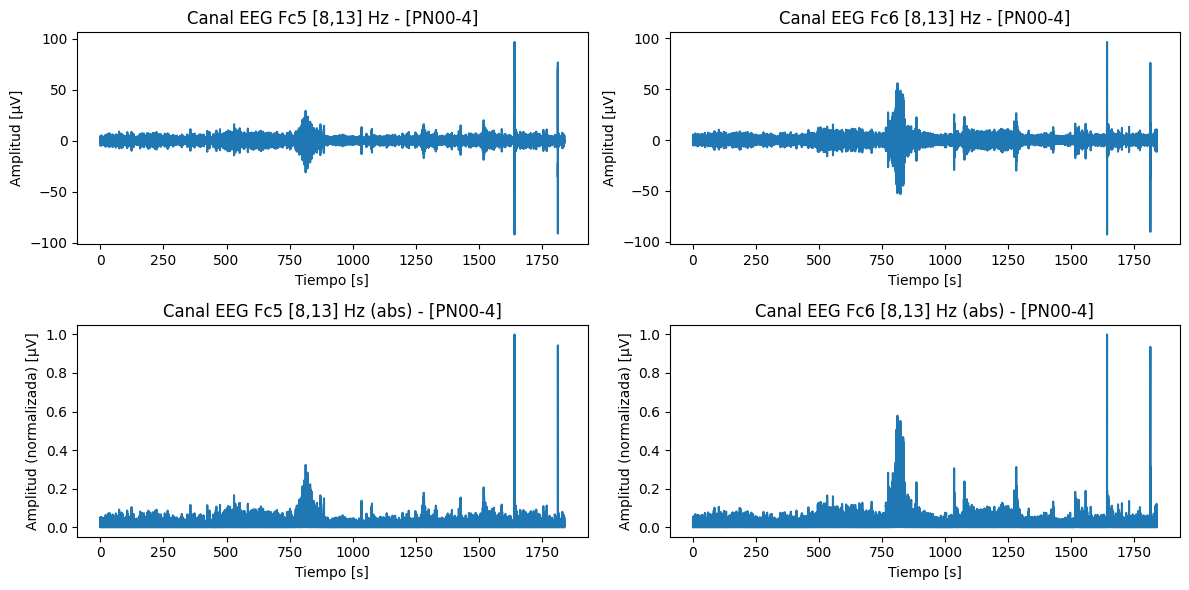


Registro PN00-5.edf



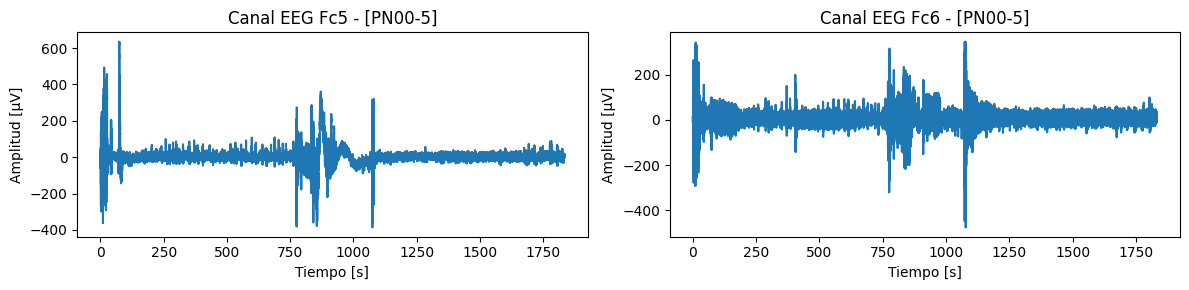

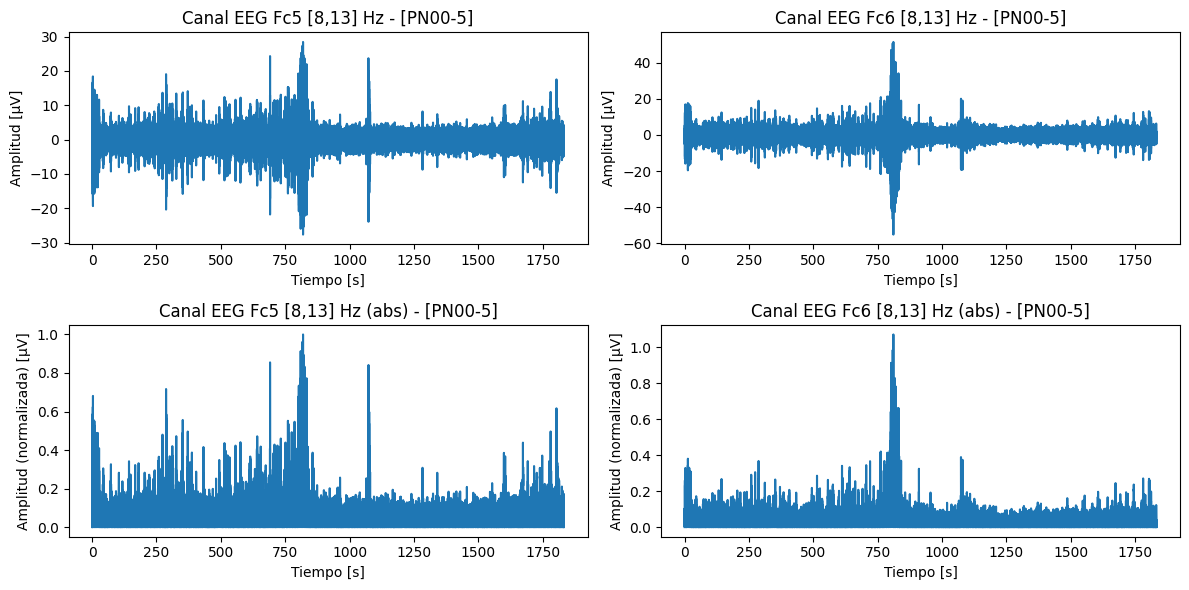

In [ ]:
#EXTRAEMOS LOS PARÁMETROS DEL PACIENTE
XX,canales,registros,crop,inicio,final,test,train,Corte,Corte2=Buscar_PN(n) #BUSCA EL NUMERO DE PACIENTE Y SUS RESPECTIVOS CANALES/REGISTROS DE INTERES EN 3 LISTAS DEFINIDAS EN INICIALIZACIÓN
paciente=diccionario_PNnum(carpeta_edfs,XX,registros,crop)
paciente_orig=copy.deepcopy(paciente) #guarda una copia no superficial de este paciente que es el original
diccionario_PNnum_pick(paciente,XX,canales) #borra de paciente los canales no deseados (los que no usan en el paper)

for i in range(0,len(paciente[f"PN{XX}"])):
  raw=paciente[f"PN{XX}"][i][0]
  raw=raw.load_data() #se ejecuta esta linea para poder usar la funcion de filtrado (.filter())
  paciente[f"PN{XX}"][i][0]=raw

filtrado(paciente,XX); #actualiza paciente a la banda de frecuencia limitada
fs=paciente[f"PN{XX}"][0][0].info["sfreq"]

#PLOTEO DEL PACIENTE ORIGINAL
for i in range(0,len(paciente_orig[f"PN{XX}"])):
  data=paciente_orig[f"PN{XX}"][i][0].get_data()*1e6
  tiempos=paciente_orig[f"PN{XX}"][i][0].times
  cont=0
  fig, ax = plt.subplots(1,len(canales), figsize=(12,3))
  print(f'\nRegistro {paciente[f"PN{XX}"][i][1]}\n')
  for canal in range(0,data.shape[0]):
    if paciente_orig[f"PN{XX}"][i][0].info["ch_names"][canal] in canales:
      nombre_canal=paciente_orig[f"PN{XX}"][i][2][canal]
      datacanal=data[canal]
      ax[cont].plot(tiempos,datacanal)
      ax[cont].set_xlabel('Tiempo [s]')
      ax[cont].set_ylabel('Amplitud [μV]')
      ax[cont].set_title(f"Canal {nombre_canal} - [{registros[i]}]")
      cont+=1
  plt.tight_layout()
  plt.show()

#PLOTEO DEL PACIENTE ORIGINAL FILTRADO EN [8,13]Hz PARA LOS CANALES DE INTERES

  data=paciente[f"PN{XX}"][i][0].get_data()*1e6
  tiempos=paciente[f"PN{XX}"][i][0].times
  fig, ax = plt.subplots(data.shape[0],2, figsize=(12,6))
  for canal in range(0,data.shape[0]):
    nombre_canal=paciente[f"PN{XX}"][i][2][canal]
    datacanal=data[canal]
    if canal==0: #si está en el primer canal lo grafica en la primera columna
      ax[canal,0].plot(tiempos,datacanal)
      ax[canal,0].set_xlabel('Tiempo [s]')
      ax[canal,0].set_ylabel('Amplitud [μV]')
      ax[canal,0].set_title(f"Canal {nombre_canal} [8,13] Hz - [{registros[i]}]")
      datacanal/=np.max(datacanal)
      ax[canal+1,0].plot(tiempos,np.abs(datacanal))
      ax[canal+1,0].set_xlabel('Tiempo [s]')
      ax[canal+1,0].set_ylabel('Amplitud (normalizada) [μV]')
      ax[canal+1,0].set_title(f"Canal {nombre_canal} [8,13] Hz (abs) - [{registros[i]}]")
    elif canal==1:
      ax[canal-1,canal].plot(tiempos,datacanal)
      ax[canal-1,canal].set_xlabel('Tiempo [s]')
      ax[canal-1,canal].set_ylabel('Amplitud [μV]')
      ax[canal-1,canal].set_title(f"Canal {nombre_canal} [8,13] Hz - [{registros[i]}]")
      datacanal/=np.max(datacanal)
      ax[canal,canal].plot(tiempos,np.abs(datacanal))
      ax[canal,canal].set_xlabel('Tiempo [s]')
      ax[canal,canal].set_ylabel('Amplitud (normalizada) [μV]')
      ax[canal,canal].set_title(f"Canal {nombre_canal} [8,13] Hz (abs) - [{registros[i]}]")
  plt.tight_layout()
  plt.show()

En los graficos superiores se muestran dos columnas con los canales de interés para la señal. En la primera fila se ven las señales EEG originales, en la segunda fila se ven los canales filtrados en la banda [8 Hz-13 Hz] con el objetivo de enfocarse en las ondas alfa, asociadas con la sincronización neuronal. Esta banda es relevante porque las alteraciones en la sincronización de estas señales pueden reflejar estados preictales. Además, el filtrado elimina ruido y componentes irrelevantes, permitiendo analizar patrones críticos relacionados con la epilepsia, como los índices de sincronización (PLI y WPLI), que muestran tendencias significativas antes de una crisis.
En la tercera fila se ven los valores absolutos de los datos obtenidos de las señales filtradas en [8 Hz-13 Hz], donde se puede apreciar como se nota un aumento de la amplitud de los datos hacia el final del registro (donde se encuentran las zonas preictal e ictal).



Registro PN00-1.edf



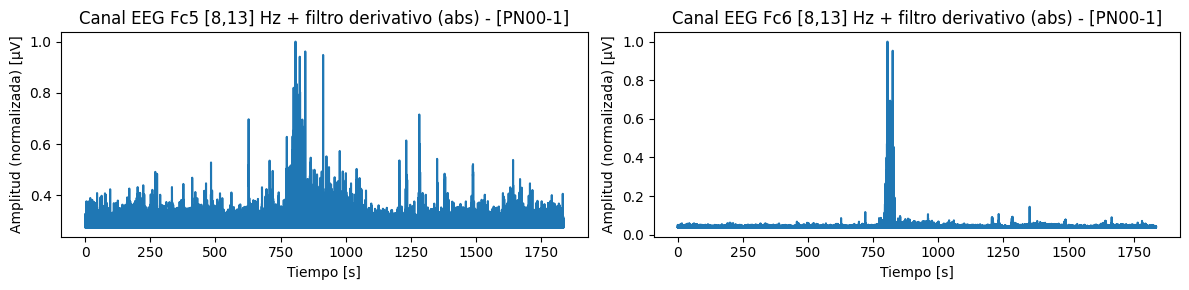


Registro PN00-2.edf



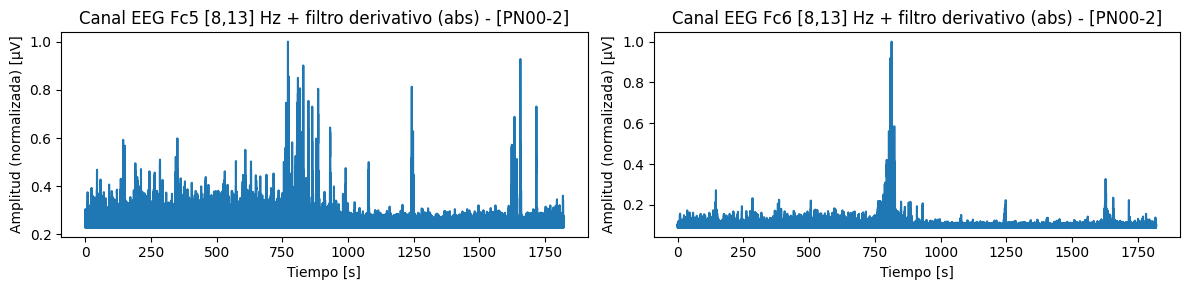


Registro PN00-3.edf



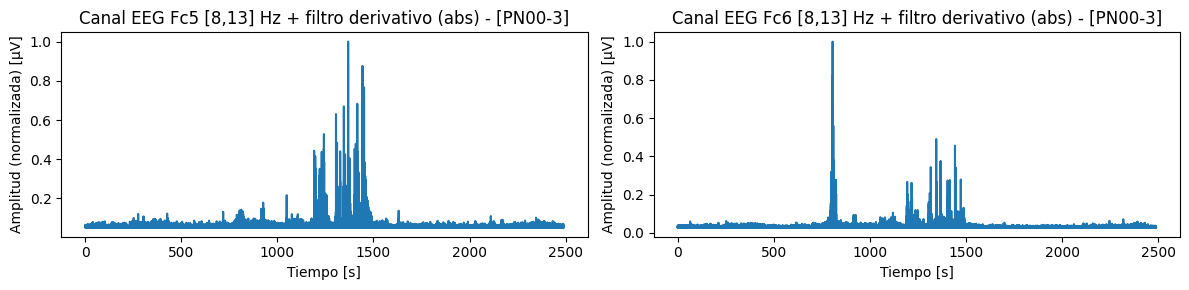


Registro PN00-4.edf



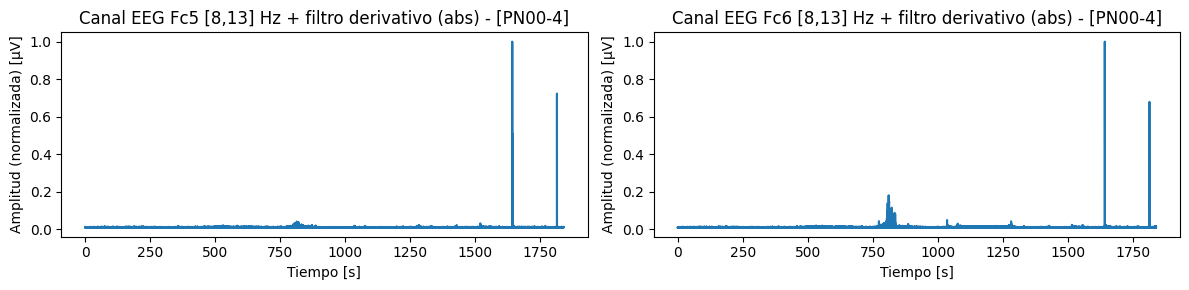


Registro PN00-5.edf



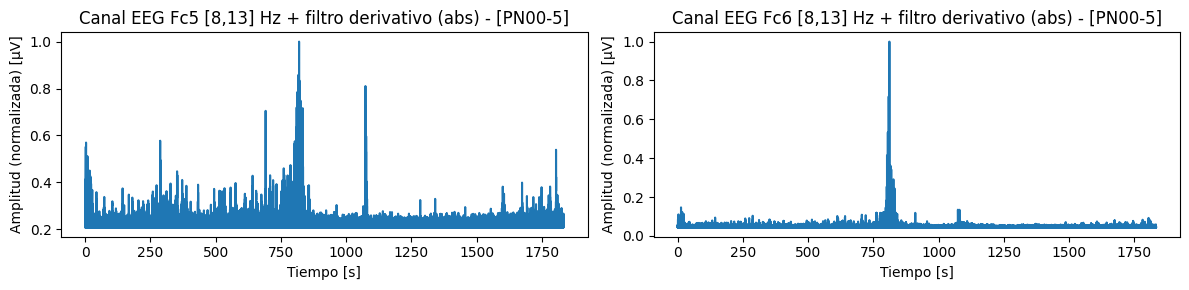

In [ ]:
#PLOTEO DEL PACIENTE FILTRADO EN [8,13]Hz Y CON FILTRO DERIVATIVO PARA LOS CANALES DE INTERES
for i in range(0,len(paciente[f"PN{XX}"])):
  data=paciente[f"PN{XX}"][i][0].get_data()*1e6
  tiempos=paciente[f"PN{XX}"][i][0].times
  print(f'\nRegistro {paciente[f"PN{XX}"][i][1]}\n')
  fig, ax = plt.subplots(1,data.shape[0], figsize=(12,3))
  for canal in range(0,data.shape[0]):
    nombre_canal=paciente[f"PN{XX}"][i][2][canal]
    datacanal=data[canal]
    datacanal=derivada(datacanal,w,fs)
    datacanal/=np.max(datacanal)
    ax[canal].plot(tiempos,datacanal)
    ax[canal].set_xlabel('Tiempo [s]')
    ax[canal].set_ylabel('Amplitud (normalizada) [μV]')
    ax[canal].set_title(f"Canal {nombre_canal} [8,13] Hz + filtro derivativo (abs) - [{registros[i]}]")
  plt.tight_layout()
  plt.show()

En los graficos superiores se demuestra la utilidad de la función derivada(datos,w,fs) para disminuir el ruido de fondo y realzar los picos de interés.
Los gráficos corresponden a la misma señal que los subplots mostrados anteriormente filtrados en [8,13] Hz y en valor absoluto, pero esta vez con el filtro derivativo aplicado. Se puede ver claramente como disminuye el ruido y aumenta la amplitud en las zonas de grandes variaciones, que corresponden a las señales de EEG preictales e ictales.

###Acondicionamiento

Se calculan las fases de los canales de interés a través de la función datos_diff(), la cual implementa la transformada de Hilbert.

In [ ]:
datos_fase=datos_diff(paciente,XX,w) #los 2 resultados tienen el formato de los datos del registro de get_data()
for i in range(0,len(paciente[f"PN{XX}"])):
  datos=paciente[f"PN{XX}"][i][0].get_data()
  datos_nuevos=datos_fase[i]

#DATOS DE FASE SIN PREPROCESAR (para plot comparativo)
from scipy.signal import hilbert
datos_registros_fase=[]
for i in range(0,len(paciente[f"PN{XX}"])):
  datos_reg_fase=[]
  raw=paciente[f"PN{XX}"][i][0] #el raw del registro i
  datos_reg=raw.get_data() #extrae los datos  de todos los canales (arrays de n canales x m datos) del registro i
  for canal in range(datos_reg.shape[0]): #para cada canal del registro i
    datos_Ch=datos_reg[canal] #datos del canal (lista)
    datos_Ch_hil=hilbert(datos_Ch)
    datos_Ch_fase=np.arctan(np.imag(datos_Ch_hil)/np.real(datos_Ch_hil))
    datos_reg_fase.append(datos_Ch_fase) #datos en fase
  datos_reg_fase=np.array(datos_reg_fase)
  datos_registros_fase.append(datos_reg_fase) #carga el array (lista con listas para cada canal) en la lista de fases


Se sobrescriben los datos de los registros por los datos de fase de cada punto del registro.

In [ ]:
paciente_2=copy.deepcopy(paciente)
for i in range(0,len(paciente[f"PN{XX}"])): #para cada registro
  info=paciente[f"PN{XX}"][i][0].info
  datos_reg_1=datos_fase[i] #este array tiene el mismo formato que los datos del raw
  datos_reg_2=datos_registros_fase[i]
  paciente_2[f"PN{XX}"][i][0]=mne.io.RawArray(datos_reg_2,info)
  paciente[f"PN{XX}"][i][0]=mne.io.RawArray(datos_reg_1,info) #crea un elemento raw con los datos procesados y la info del raw de paciente y lo usa para sobrescribir el raw del registro de

###Ventaneo

Se ventanea los registros en ventanas de 6 segundos de duración solapadas 1 segundo. Esto permite asumir estacionariedad en sentido amplio.

In [ ]:
paciente_epoch,N=ventaneo(paciente,duracion,overlap,XX)
paciente_epoch_2,_=ventaneo(paciente_2,duracion,overlap,XX)

In [ ]:
for i in range(len(paciente_epoch[f"PN{XX}"])):
  num_vent=len(paciente_epoch[f"PN{XX}"][i][0])
  tiempos=paciente[f"PN{XX}"][i][0].times
  print(f"Cantidad de ventanas {paciente_epoch[f'PN{XX}'][i][1]}",num_vent) #cantidad de ventanas

print("\nPuntos por ventana: ",N)

Cantidad de ventanas PN00-1.edf 306
Cantidad de ventanas PN00-2.edf 303
Cantidad de ventanas PN00-3.edf 414
Cantidad de ventanas PN00-4.edf 306
Cantidad de ventanas PN00-5.edf 305

Puntos por ventana:  3072.0


###PLI & WPLI

Se computan los índices de sincronización PLI y WPLI para cada ventana de los registros.

In [ ]:
diccionario_PLI=PLI(paciente_epoch,XX,N)
diccionario_WPLI=WPLI(paciente_epoch,XX,N)
diccionario_PLI_2=PLI(paciente_epoch_2,XX,N) #PLI con datos sin preprocesamiento (filtro derivativo)
diccionario_WPLI_2=WPLI(paciente_epoch_2,XX,N) #WPLI con datos sin preprocesamiento (filtro derivativo

Registro: PN00-1.edf 



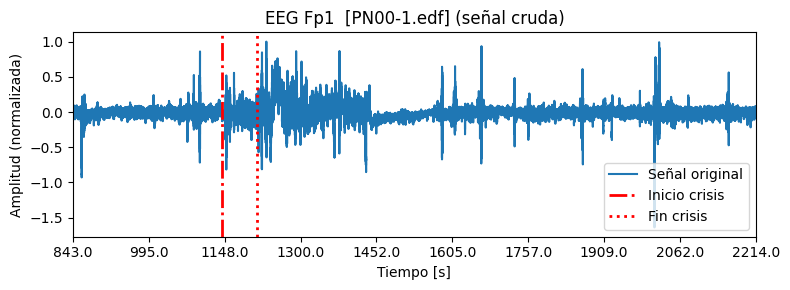

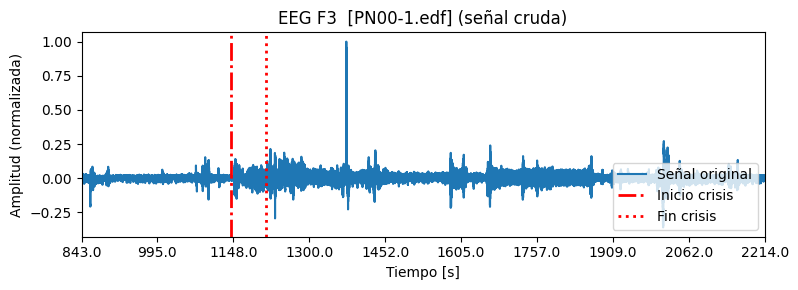

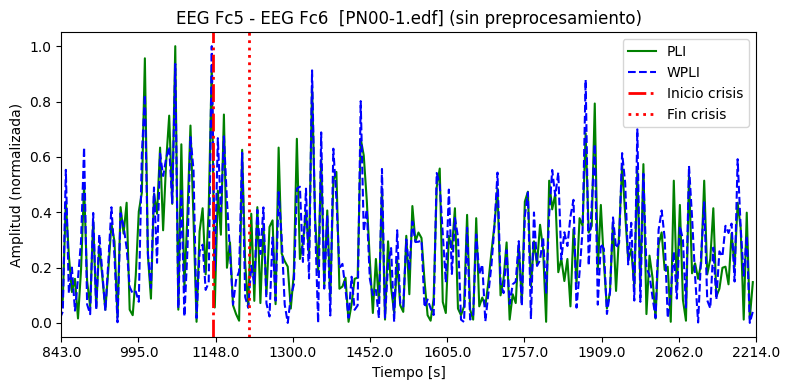

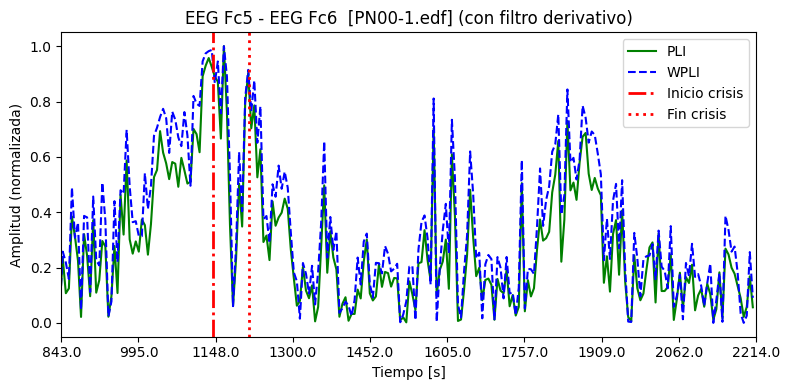



Registro: PN00-2.edf 



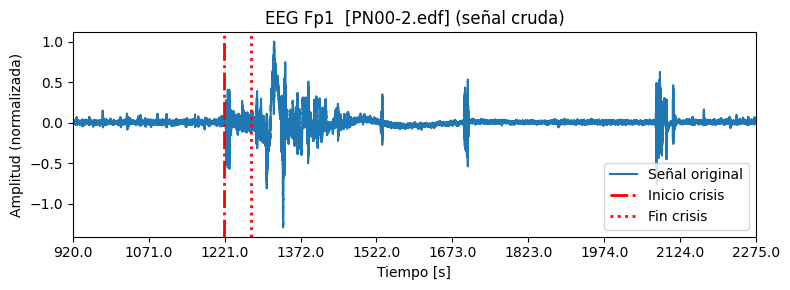

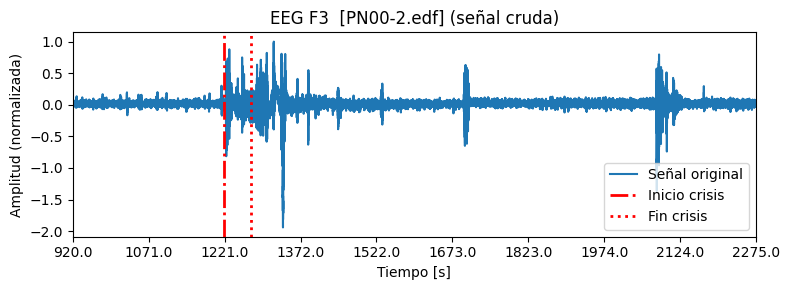

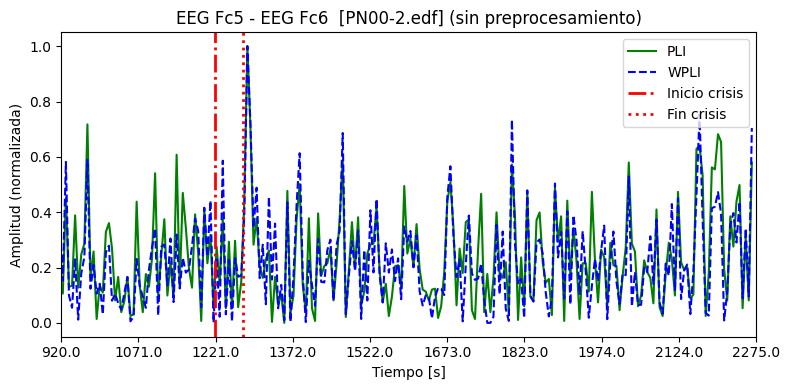

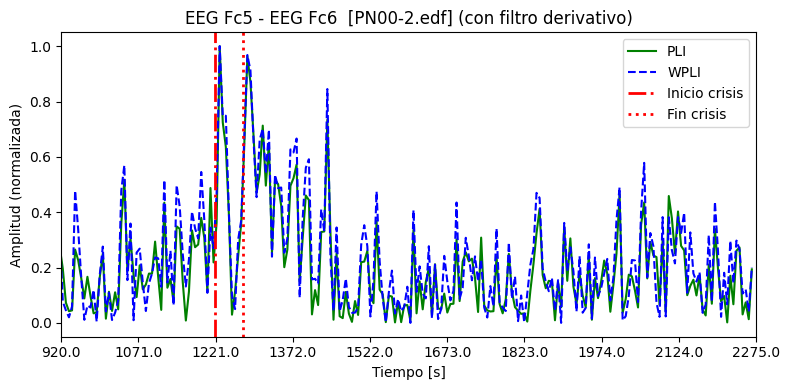



Registro: PN00-3.edf 



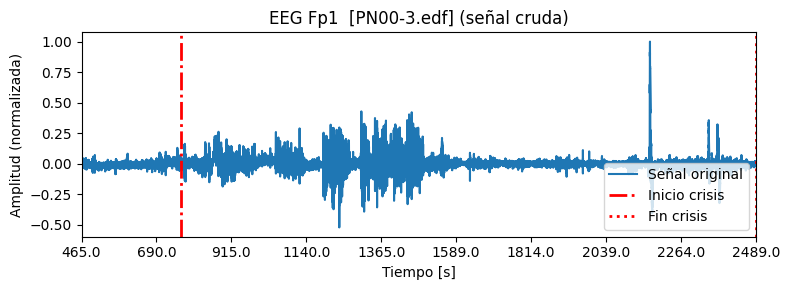

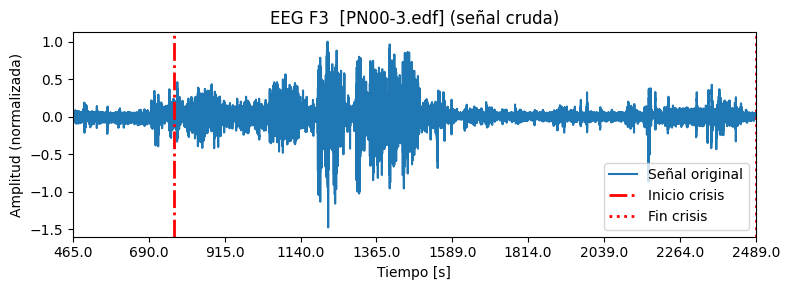

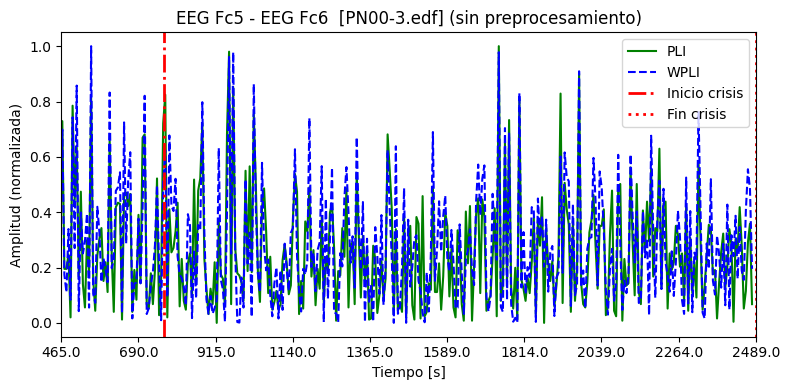

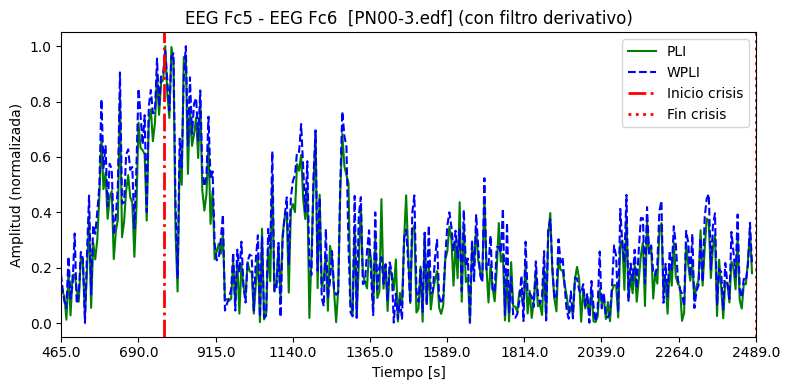



Registro: PN00-4.edf 



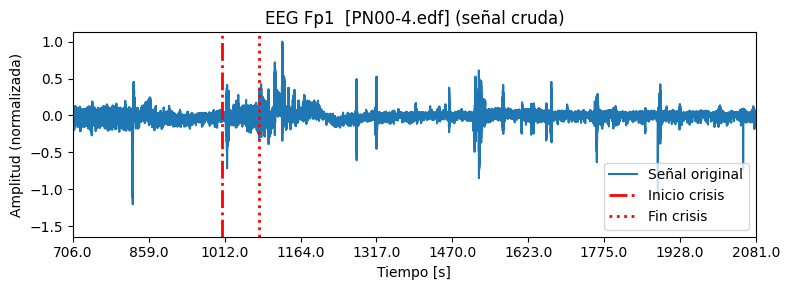

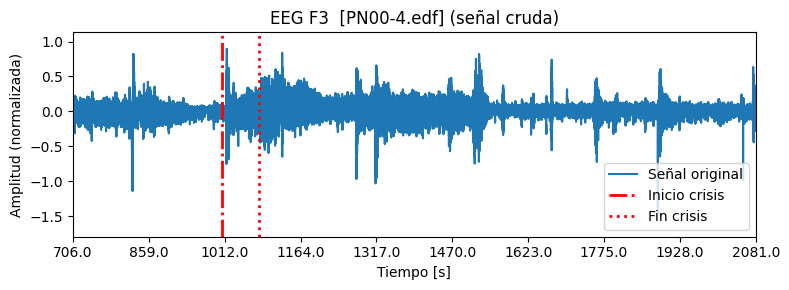

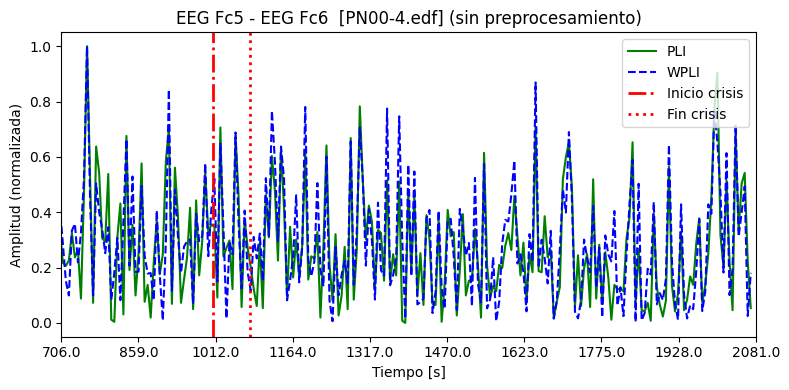

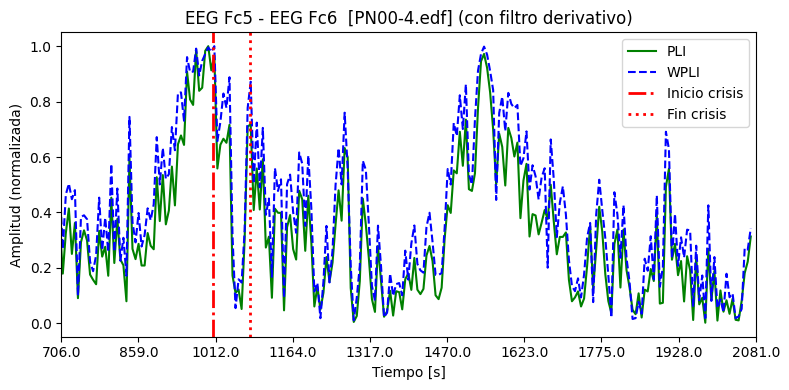



Registro: PN00-5.edf 



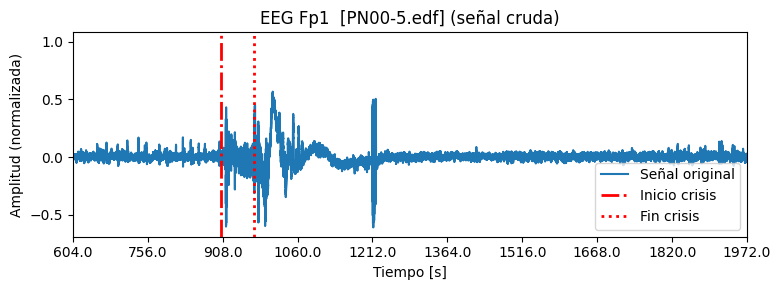

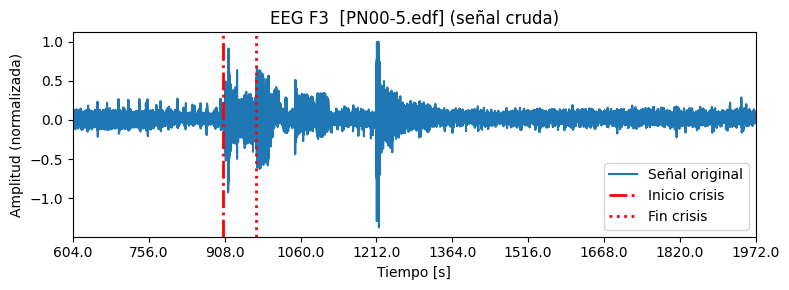

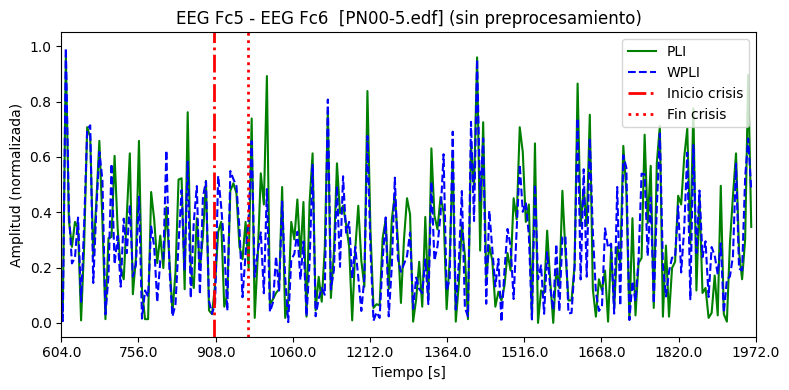

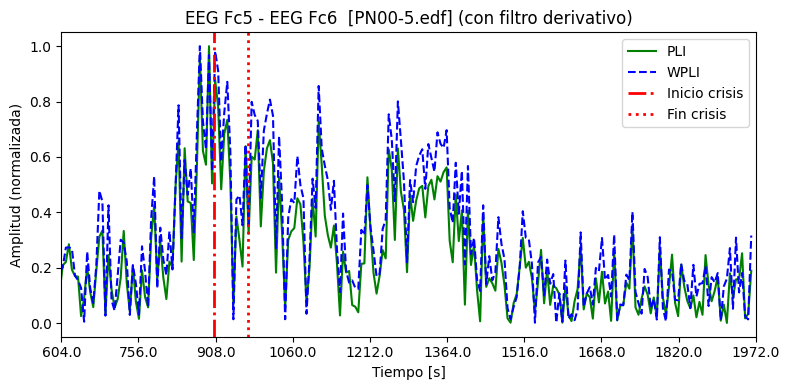

In [ ]:
for i in range(0,len(diccionario_PLI[f"PN{XX}"])): #para cada registro
  datos_PLI=diccionario_PLI[f"PN{XX}"][i][0]
  datos_WPLI=diccionario_WPLI[f"PN{XX}"][i][0]
  datos_WPLI_sp=diccionario_WPLI_2[f"PN{XX}"][i][0]
  datos_PLI_sp=diccionario_PLI_2[f"PN{XX}"][i][0]
  max_PLI=np.max(datos_PLI)
  datos_PLI/=max_PLI #normaliza
  max_WPLI=np.max(datos_WPLI)
  datos_WPLI/=max_WPLI #normaliza
  max_WPLI_sp=np.max(datos_WPLI_sp)
  datos_WPLI_sp/=max_WPLI_sp #normaliza
  max_PLI_sp=np.max(datos_PLI_sp)
  datos_PLI_sp/=max_PLI_sp #normaliza

  print("Registro:",paciente_epoch[f'PN{XX}'][i][1],"\n")
  #PLOTEO DE LA SEÑAL ORIGINAL (CRUDA, SIN FILTRAR EN ALPHA)
  data=paciente_orig[f"PN{XX}"][i][0].get_data()*1e6
  tiempos_orig=paciente_orig[f"PN{XX}"][i][0].times #puede ser distinto a tiempos por el solapamiento del ventaneo
  for canal in range(data.shape[0]):
    nombre_canal=paciente_orig[f"PN{XX}"][i][2][canal]
    datacanal=data[canal]
    datacanal/=np.max(datacanal)
    if paciente_orig[f"PN{XX}"][i][0].info["ch_names"][canal] in canales:
      plt.figure(figsize=(8,3))
      plt.plot(tiempos_orig,datacanal,label="Señal original")
      plt.axvline(Corte,color="red",label="Inicio crisis",linewidth=2,linestyle="-.")
      plt.axvline(Corte+final[i]-inicio[i],color="red",label="Fin crisis",linewidth=2,linestyle=":")
      plt.legend([f"{nombre_canal} - PN{XX}"])
      plt.ylabel("Amplitud (normalizada)")
      plt.xlabel('Tiempo [s]')
      plt.legend(["Señal original","Inicio crisis","Fin crisis"],loc="lower right")
      plt.xticks(np.linspace(Corte-300,crop[i][1]-crop[i][0],10),np.round(np.linspace(crop[i][0]+Corte-300,crop[i][1],10)))
      plt.xlim(Corte-300,crop[i][1]-crop[i][0])
      plt.title(f"{nombre_canal}  [{paciente_epoch[f'PN{XX}'][i][1]}] (señal cruda)")
    plt.tight_layout()
  plt.show()

  #PLOTEO DE LOS FEATURES
  tiempos=paciente[f"PN{XX}"][i][0].times
  num_vent=len(paciente_epoch[f"PN{XX}"][i][0])
  while len(tiempos[::int(N)])!=num_vent:
    tiempos=np.delete(tiempos,[-1])

  plt.figure(figsize=(8,4))
  plt.plot(tiempos[::int(N)],datos_PLI_sp[::],label="PLI",color='g') #tiempos tomados de a N de forma tal de asignar un punto de tiempo x ventana
  plt.plot(tiempos[::int(N)],datos_WPLI_sp[::],label="WPLI",color='b',linestyle="--")
  plt.axvline(Corte,color="red",label="Inicio crisis",linewidth=2,linestyle="-.")
  plt.axvline(Corte+final[i]-inicio[i],color="red",label="Fin crisis",linewidth=2,linestyle=":")
  plt.legend(["PLI","WPLI","Inicio crisis","Fin crisis"],loc="upper right")
  plt.xlabel('Tiempo [s]')
  plt.ylabel('Amplitud (normalizada)')
  plt.xticks(np.linspace(Corte-300,crop[i][1]-crop[i][0],10),np.round(np.linspace(crop[i][0]+Corte-300,crop[i][1],10)))
  plt.xlim(Corte-300,crop[i][1]-crop[i][0])
  plt.title(f"{canales[0]} - {canales[1]}  [{paciente_epoch[f'PN{XX}'][i][1]}] (sin preprocesamiento)")
  plt.tight_layout()
  plt.show()

  plt.figure(figsize=(8,4))
  plt.plot(tiempos[::int(N)],datos_PLI[::],label="PLI",color='g') #tiempos tomados de a N de forma tal de asignar un punto de tiempo x ventana
  plt.plot(tiempos[::int(N)],datos_WPLI[::],label="WPLI",color='b',linestyle="--")
  plt.axvline(Corte,color="red",label="Inicio crisis",linewidth=2,linestyle="-.")
  plt.axvline(Corte+final[i]-inicio[i],color="red",label="Fin crisis",linewidth=2,linestyle=":")
  plt.legend(["PLI","WPLI","Inicio crisis","Fin crisis"],loc="upper right")
  plt.xlabel('Tiempo [s]')
  plt.ylabel('Amplitud (normalizada)')
  plt.xlim(Corte-300,crop[i][1]-crop[i][0])
  plt.xticks(np.linspace(Corte-300,crop[i][1]-crop[i][0],10),np.round(np.linspace(crop[i][0]+Corte-300,crop[i][1],10)))
  plt.title(f"{canales[0]} - {canales[1]}  [{paciente_epoch[f'PN{XX}'][i][1]}] (con filtro derivativo)")
  plt.tight_layout()
  plt.show()
  print("\n")

En los primeros dos plots superiores se pueden ver primero las señales de los canales utilizados para el cálculo de PLI/WPLI (crudas, sin filtrar en la banda Alpha). El tercer plot muestra los índices de sincronización PLI y WPLI calculados sin un preprocesamiento con un filtro derivativo, cuyo efecto se evidencia en el cuarto plot. Este último muestra las métricas PLI y WPLI, que cuantifican la sincronización de fase entre las señales EEG de este par de canales. La tendencia creciente en las curvas en los tiempos correspondientes al período preictal, definido como el lapso de 300s previo a la crisis (contenida entre las lineas rojas), indica un aumento en la sincronización entre las dos señales. Esto es relevante porque, en contextos de epilepsia, se ha demostrado que un incremento en la sincronización de fase suele preceder a una crisis epiléptica [2], reflejando la activación anómala de redes neuronales sincronizadas.

El cálculo del PLI y WPLI resulta particularmente útil porque, por un lado, el PLI descarta contribuciones de fase cercanas a 0 (mod π), lo que reduce la influencia del ruido o volumen conducido. Por otro lado, el WPLI pondera los desfases según su magnitud, aumentando la sensibilidad en detectar sincronización verdadera y reduciendo falsos positivos.
En general, estas métricas proporcionan una evaluación robusta de la sincronización, incluso en señales con ruido, y son indicadores valiosos del estado preictal. La alineación entre ambas métricas valida la tendencia observada en la sincronización.





##Machine Learning

En esta sección se desarrollan dos modelos de *machine learning* con el objetivo de determinar si las ventanas de tiempo de la señal que se está analizando corresponden al intervalo preictal. Detti, et al (2017,2019) define como período preictal a los 300s previos al inicio de una crisis. Esta medida de tiempo fue utilizada para el etiquetado de las ventanas de los registros de entrenamiento, en el que la etiqueta 0 indica que la ventana es postictal o interictal, y 1 que la ventana es preictal. La correcta clasificación de las ventanas de este período permite predecir una crisis epiléptica en un tiempo de predicción de hasta 300s antes de su comienzo, donde el tiempo de predicción se calcula como la diferencia entre el tiempo de inicio de la crisis y el tiempo en el cual se detecta **correctamente** la primera ventana preictal.

Los algoritmos de *machine learning* implementados en el presente trabajo fueron Random Forest (RF) y Support Vector Machine (SVM), debido a su robustez y capacidad de generalización en la clasificación de señales fisiológicas.

*  RF es un algoritmo basado en la combinación de múltiples árboles de decisión, lo que permite reducir el sobreajuste y mejorar la precisión del modelo. RF es particularmente útil para la clasificación de señales EEG, ya que puede manejar datos con alta dimensionalidad y seleccionar automáticamente las características más relevantes para la predicción.

*  SVM es una técnica de clasificación que busca encontrar el hiperplano óptimo que separa las clases con la mayor distancia posible. En el contexto de EEG, SVM es eficaz en la identificación de patrones complejos y ha demostrado ser una herramienta poderosa en la detección de estados pre-ictales.

Además, se aplicó un método basado en la técnica Moving Average and Amplitude Convergence/Divergence (MAACD), la cual ha sido utilizada en estudios previos para mejorar la predicción de crisis epilépticas a partir de señales EEG (Detti, et al; 2017). MAACD es una variante del Moving Average Convergence/Divergence (MACD), un indicador comúnmente usado en análisis de tendencias financieras, pero adaptado al análisis de sincronización de señales EEG. Su objetivo es capturar tendencias ascendentes en las medidas de sincronización entre distintos canales de EEG, lo que permite identificar cambios en la actividad neuronal previos a una crisis.



### Preacondicionamiento

El diccionario paciente cargado con los datos de fase de los registros del paciente XX se vacía y se carga nuevamente con los datos crudos de los registros. Luego estos datos son filtrados con un pasabandasa entre 0.5 Hz y 100 Hz de forma tal de eliminar los ruidos de deriva y de alta frecuencia. Posteriormente las señales se filtran con un filtro notch, eliminando el ruido de línea a 50 Hz.

Por otro lado, los tiempos de inicio y finalización de cada crisis se vuelven a computar teniendo en cuenta el crop temporal realizado a los registros al momento de la carga. Utilizando estos tiempos y la frecuencia de muestreo se calcula el punto del registro en el cual comienza y termina cada crisis. Estos puntos serán utiizados luego como parámetro de input de la función de extracción de features, en donde se utilizan para etiquetar las ventanas como preictales (1) o interictales (0).



In [ ]:
from typing_extensions import NamedTuple

paciente.clear() #vacia el diccionario
for i in range(0,len(paciente_orig[f"PN{XX}"])): #vuelve a llenar paciente con la información de los canales crudos (estaba cargado con datos de fase)
  raw_orig=paciente_orig[f"PN{XX}"][i][0].pick_channels(canales)
  datos_orig=raw_orig.get_data()*1e6
  info=raw_orig.info
  raw=mne.io.RawArray(datos_orig,info)
  paciente.setdefault(f"PN{XX}",[]).append([raw,paciente_orig[f"PN{XX}"][i][1],paciente_orig[f"PN{XX}"][i][2]])

for i in range(len(paciente[f"PN{XX}"])):
  paciente[f"PN{XX}"][i][0].notch_filter(freqs=[50],notch_widths=2)  #rechaza 50 Hz con notch
  paciente[f"PN{XX}"][i][0].filter(0.5,100) #pasabanda para eliminar deriva y altas frecuencias

#rearmado de tiempos de crisis para que considere el crop del principio
for i in range(len(paciente[f"PN{XX}"])):
  inicio_reg=Corte
  final_reg=Corte+final[i]-inicio[i]
  punto_inicio=int(inicio_reg*fs)
  punto_final=int(final_reg*fs)


###Extracción de Features

FEATURES EXTRAÍDOS:

---
* 4 features de sincronización (PLI, WPLI, MAACD_pli, MAACD_wpli)
* 5 features de Wavelet (media, desvio, maximo, minimo, rango pico a pico) x (4 detalles + 1 aproximación)
* 9 features en el dominio temporal (media, varianza, desvío, curtosis, asimetría, energía, potencia, rango pico a pico y cruce por cero)
* 2 features en el dominio frecuencial (centroide, frecuencia dominante)
* 6 features por banda de frecuencia (media, desvío, máximo, mínimo, rango pico a pico, potencia) x 6 bandas

  => Total: $4+5\cdot5+9+2+6\cdot6=76$ features

In [ ]:
#extracción de features
epoch,N=ventaneo(paciente,duracion,overlap,XX) #creación de registros con ventanas a etiquetar
features_y_etiquetas,features_testeo=features_etiquetas(epoch,N,diccionario_PLI,diccionario_WPLI,fs,duracion,overlap,punto_inicio,punto_final,XX,test,train) #diccionario con clave PN{XX} y contenido [features,etiquetas]


La implementación de *machine learning* realizada en este trabajo se fundamenta en la utilización de todos los registros asociados al paciente analizado. Estos registros se dividen en **registros de entrenamiento** y **registros de testeo.**

Los registros de entrenamiento son aquellos con cuyos features y etiquetas se entrena a los clasificadores. Los registros de testeo (uno por paciente), por su parte, son aquellos con los cuales se prueba el desempeño de los algoritmos de clasificación cuando el input es un registro sin etiquetar. En otras palabras, ambos tipos de registros presentan los mismos *features*, pero sólo los de entrenamiento están etiquetados. Las etiquetas asignadas a los registros de testeo serán generadas exclusivamente por los clasificadores ya entrenados.

Resulta importante mencionar que, una vez extraídos los features de todos los registros de entrenamiento, estos se normalizan con StandardScaler() y se reducen mediante el método de *Principal Component Analysis* (PCA). Este último es un método de reducción de dimensionalidad utilizado para disminuir la cantidad de variables en un conjunto de datos a la vez que se conserva la mayor parte de la información. Naturalmente, este método implica sacrificar precisión, pero permite ganar simplicidad computacional. Los componentes principales pasan a ser los nuevos *features*, y se construyen con combinaciones lineales que maximizan la varianza de los *features* originales.

Una vez eliminadas las redundancias estadísticas de los features con PCA, estos se juntan en un único array global para su división en conjuntos de entrenamiento y testeo  globales (80% y 20% de los datos, respectivamente). El ratio de entrenamiento/testeo 80:20 asegura que la distribución de las clases sea equilibrada mediante una estrategia de estratificación.

Las etiquetas de los registros de entrenamiento, por otra parte, se juntan en un único array global y se codifican utilizando LabelEncoder().

La utilización de los features y etiquetas de todos los registros de entrenamiento en simultáneo permite entrenar a los algoritmos de clasificación una única vez con todos los datos, aumentando la eficacia y la eficiencia del modelo al momento de predecir las etiquetas de un registro en particular sin etiquetar (registro de testeo).

In [ ]:
#features en conjunto de todos los registros
X_regs=np.vstack([features_y_etiquetas[f"PN{XX}"][i][0] for i in range(len(features_y_etiquetas[f"PN{XX}"]))]) #junta los features de todos los registros ventaneados
y_regs=np.concatenate([features_y_etiquetas[f"PN{XX}"][i][1] for i in range(len(features_y_etiquetas[f"PN{XX}"]))]) #junta las etiquetas de todos los registros ventaneados

#estandarización de features
scaler=StandardScaler()
X_regs_esc=scaler.fit_transform(X_regs)

#Principal Component Analysis para eliminar redundancias en los features
pca=PCA(n_components=10)
X_pca=pca.fit_transform(X_regs_esc)

#codificación de etiquetas
le=LabelEncoder()
y_regs_cod=le.fit_transform(y_regs)

#balanceo de clases
under_sampler=RandomUnderSampler(random_state=42)
X_regs_under,y_regs_under=under_sampler.fit_resample(X_regs_esc,y_regs_cod)
over_sampler=RandomOverSampler(random_state=42)
X_regs_bal,y_regs_bal=over_sampler.fit_resample(X_regs_under,y_regs_under)

#división en conjunto de entrenamiento y prueba globales
X_train,X_test,y_train,y_test=train_test_split(X_regs_bal,y_regs_bal,test_size=0.2,random_state=42,stratify=y_regs_bal)


###Evaluación de los modelos

Para la evaluación de los modelos se calcularon las siguientes métricas que permiten la visualización del desempeño de estos.

Precisión (Accuracy): Proporción de predicciones correctas.
$$\text{Precisión} = \frac{TP}{TP + FP}$$
Sensibilidad (Recall o TPR, True Positive Rate): Proporción de ventanas ictales correctamente identificadas. Es crucial si el objetivo es detectar crisis a tiempo.
$$\text{Recall} = \frac{TP}{TP + FN}$$

Especificidad (TNR, True Negative Rate): Proporción de ventanas preictales correctamente identificadas. Es importante para evitar falsas alarmas.
$$\text{TNR}=\frac{TN}{TN + FP}$$

F1-score: Promedio armónico entre precisión y sensibilidad. Es útil cuando hay un desbalance entre clases.
$$\text{F1-score} = 2\cdot\frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$
El G-Mean (Geometric Mean) es una métrica útil cuando las clases están desbalanceadas, como en la clasificación ictal/preictal. Se define como:
$$\text{G-Mean} = \sqrt{\text{Recall}\cdot \text{TNR}}$$


####Modelo RANDOM FOREST



#####Entrenamiento y validación

Para la clasificación de las señales EEG en estados preictales e interictales, se entrenó un modelo basado en la técnica de Random Forest. El modelo fue configurado con 100 árboles de decisión y una semilla aleatoria fija (random_state=42) para garantizar la reproducibilidad de los resultados.

Tras el entrenamiento del modelo con los conjuntos globales X_train e y_train, se procedió a la evaluación sobre el conjunto de datos de testeo globales (X_test). Para cada muestra, se generaron predicciones y se compararon con las etiquetas reales para obtener métricas de desempeño.


EVALUACIÓN DE DESEMPEÑO MODELO RANDOM FOREST:

              precision    recall  f1-score   support

           0       0.80      0.83      0.82        48
           1       0.82      0.79      0.80        47

    accuracy                           0.81        95
   macro avg       0.81      0.81      0.81        95
weighted avg       0.81      0.81      0.81        95


G-mean: 0.8103

Matriz de confusión:



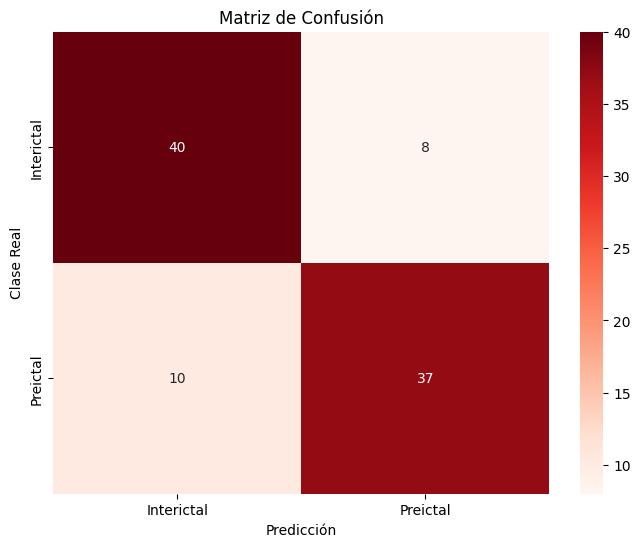


Curva ROC: 



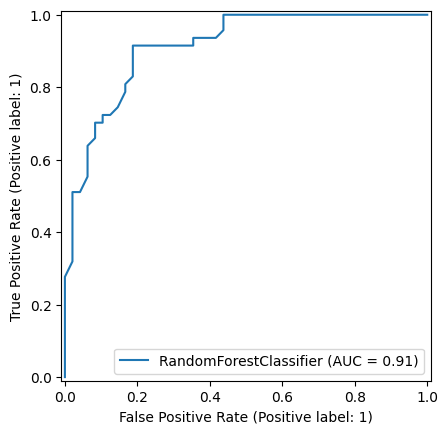

In [ ]:
#entrenamiento de Modelo RANDOM FOREST
modelo=RandomForestClassifier(random_state=42,n_estimators=100) #entrenamiento del modelo Random Forest
modelo.fit(X_train,y_train) #testeo del modelo

#TESTEO
y_pred=modelo.predict(X_test) #predicción con el modelo ya entrenado
nombres_target=[str(label) for label in le.classes_]
nombres_clases=["Interictal","Preictal"] #definición de las clases a etiquetar [0,1]

#métricas de performance
print("\nEVALUACIÓN DE DESEMPEÑO MODELO RANDOM FOREST:\n")
print(classification_report(y_test,y_pred,target_names=nombres_target))

#G-mean
gmean=geometric_mean_score(y_test,y_pred,average='macro')
print(f"\nG-mean: {gmean:.4f}")

#matriz de confusión
matriz=confusion_matrix(y_test,y_pred)
print("\nMatriz de confusión:\n")
plt.figure(figsize=(8,6))
sns.heatmap(matriz,annot=True,fmt='d',cmap='Reds',xticklabels=nombres_clases,yticklabels=nombres_clases)
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Clase Real")
plt.show()

#CURVA ROC
print("\nCurva ROC: \n")
metrics.RocCurveDisplay.from_estimator(modelo,X_test,y_test)
plt.show()

#####Evaluación del modelo

Para verificar la capacidad del modelo en la predicción de eventos preictales, se prueba el modelo entrenado con registros de un paciente, con un registro no etiquetado del mismo paciente.

El modelo generó predicciones sobre este nuevo registro y se compararon con las etiquetas* reales (1 para aquellas ventanas cuyo inicio y fin pertenezca al intervalo de predicción, 0 para el resto) para medir la precisión del sistema. Se analizaron métricas como la tasa de falsos positivos y falsos negativos, evaluando cuán confiable es el modelo para identificar correctamente los eventos preictales.

De acuerdo a lo desarrollado por Detti, el tal; (2017), si un clasificador aplicado sobre un *dataset* sin etiquetar clasifica correctamente al menos una ventana dentro del intervalo de predicción, se considera que la crisis fue predicha correctamente. Por otro lado, si se etiqueta como 1 a una ventana por fuera del intervalo de predicción, la misma debe ser considerada como un falso positivo. Los falsos negativos corresponderán a aquellas ventanas situadas dentro del intervalo de predicción cuya etiqueta asignada sea 0.


*Nota: estas etiquetas fueron computadas manualmente. El registro de testeo únicamente presenta features. Las etiquetas reales son calculadas luego de realizada la predicción, utilizando la definición de período preictal y los tiempos de inicio/final de crisis calculados en el preprocesamiento.

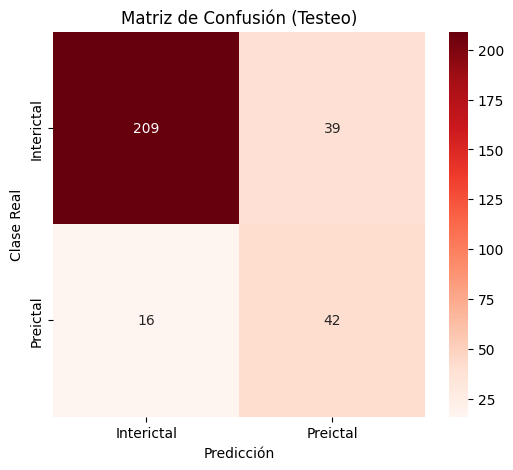


Registro PN00-1.edf: Tiempo de predicción = 245.00 s


EVALUACIÓN DEL MODELO RANDOM FOREST (Testeo):

Precisión (Accuracy): 0.8203
Precisión Positiva (Precision): 0.5185
Sensibilidad (Recall): 0.7241
Puntaje F1: 0.6043

Reporte de Clasificación (Testeo):

              precision    recall  f1-score   support

  Interictal       0.93      0.84      0.88       248
    Preictal       0.52      0.72      0.60        58

    accuracy                           0.82       306
   macro avg       0.72      0.78      0.74       306
weighted avg       0.85      0.82      0.83       306


G-mean: 0.7834399332591768


In [ ]:
features_05=features_testeo

#creamos los contadores globales
V_pos=0
F_pos=0
F_neg=0
V_neg=0

for i in range(len(features_05[f"PN{XX}"])): #para cada registro de testeo
  #testeo de Modelo SUPPORT VECTOR MACHINE (en cada registro)
  inicio_05=Corte
  final_05=Corte+final[i+len(train)]-inicio[i+len(train)]
  X_05=np.vstack([features_05[f"PN{XX}"][i][0]])
  X_05_esc=scaler.transform(X_05)

  #predicción de clases
  y_05_pred=modelo.predict(X_05_esc)

  cont=0
  cont_2=0
  cont_3=0
  cont_4=0
  for j, etiqueta in enumerate(y_05_pred): #para cada ventana
    desplazamiento=N*(1-overlap/duracion) #desplazamiento por ventana
    inicio_aux=j*desplazamiento #punto de inicio de la ventana a la que corresponde la etiqueta
    final_aux=inicio_aux+N-1 #punto final de la ventana a la que corresponde la etiqueta
    t_inicio=inicio_aux/fs
    t_final=final_aux/fs
    positivos_reales=math.ceil(300/((final_aux-inicio_aux-1)/fs))

    if etiqueta==1 and inicio_aux>inicio_05*fs-300*fs and final_aux<inicio_05*fs and cont==0:
      t_pred=inicio_05-t_inicio
      cont+=1
    elif etiqueta==1 and inicio_aux>inicio_05*fs-300*fs and final_aux<inicio_05*fs and cont>0:
      cont+=1 #positivos reales
    elif etiqueta==1 and (inicio_aux<inicio_05*fs-300*fs or final_aux>inicio_05*fs):
      cont_2+=1 #falso positivo
    elif etiqueta==0 and inicio_aux>inicio_05*fs-300*fs and final_aux<inicio_05*fs:
      cont_3+=1 #falso negativo
    else:
      cont_4+=1 #negativos reales

  V_pos+=cont
  F_pos+=cont_2
  F_neg+=cont_3
  V_neg+=features_05[f"PN{XX}"][i][2]-cont-cont_2-cont_3 #o lo que es lo mismo, cont_4

#listas de valores reales y predichos
y_true_global=[1]*V_pos+[0]*V_neg+[1]*F_neg+[0]*F_pos
y_pred_global=[1]*V_pos+[0]*V_neg+[0]*F_neg+[1]*F_pos

#matriz de confusión
matriz_confusion=confusion_matrix(y_true_global,y_pred_global)
plt.figure(figsize=(6,5))
sns.heatmap(matriz_confusion,annot=True,fmt='d',cmap='Reds',xticklabels=["Interictal","Preictal"],yticklabels=["Interictal","Preictal"])
plt.xlabel("Predicción")
plt.ylabel("Clase Real")
plt.title("Matriz de Confusión (Testeo)")
plt.show()

#métricas de desempeño globales
accuracy=accuracy_score(y_true_global,y_pred_global)
precision=precision_score(y_true_global,y_pred_global)
recall=recall_score(y_true_global,y_pred_global)
f1=f1_score(y_true_global,y_pred_global)
gmean=geometric_mean_score(y_true_global,y_pred_global,average='macro')

#Reporte de clasificación global
print(f"\nRegistro {features_05[f'PN{XX}'][i][1]}: Tiempo de predicción = {t_pred:.2f} s\n")
print("\nEVALUACIÓN DEL MODELO RANDOM FOREST (Testeo):\n")
print(f"Precisión (Accuracy): {accuracy:.4f}")
print(f"Precisión Positiva (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"Puntaje F1: {f1:.4f}")

print("\nReporte de Clasificación (Testeo):\n")
print(classification_report(y_true_global,y_pred_global,target_names=["Interictal","Preictal"]))
print("\nG-mean:",gmean)


#####Postprocesamiento

Para disminuir la cantidad de falsas alarmas (falsos positivos) se realiza un postprocesamiento en el cual se truncan los resultados de la clasificación utilizando un kernel incremental de forma iterativa a lo largo de todas las etiquetas asignadas. Esencialmente, este kernel encuentra etiquetas preictales/interictales aisladas o azarosas y las muta a su clase correspondiente (convierte en 0 a los 1 rodeados de 0, en 1 a los 0 rodeadeos de 1). Luego el kernel incrementa su longitud y vuelve a escanear las nuevas etiquetas para encontrar patrones azarosos. Esta idea aunque modificada, se basa en la utilizada en Detti, et al (2019) para el mismo propósito.

El algoritmo de postprocesamiento se fundamenta en el hecho de que únicamente en el período preictal (300 s) debería haber una secuencia de 1s consecutivos, mientras que en el resto de las ventanas las etiquetas deberían ser 0s consecutivos. De este modo, unos pocos 1s aislados entre muchos 0s tendrán una alta probabilidad de ser falsos positivos y un 0 aislado entre muchos 1s de ser un falso negativo. Empíricamente, se determinó que los umbrales que mejor rendimiento generan son más de un 40% de 0s dentro del kernel para convertir las etiquetas correspondientes a 0, y al menos un 50% de 1s para convertirlas a 1. Estos umbrales permitieron mejorar la precisión y la sensibilidad de forma simultánea. En el modelo Random Forest, un kernel con longitudes entre 2 y 4, e incrementadas con un paso de 1 demostró dar los mejores resultados.

In [ ]:
#POSTPROCESAMIENTO
#Período ictal/postictal/interictal compuesto por seguidilla de 0s. Periodo preictal compuesto por seguidilla de 1s.
#Se busca eliminar 1s y 0s colocados de manera aislada (errónea) mediante un kernel incremental.
#Si más del 40% del kernel está compuesto por 0s todas las etiquetas en esas posiciones se pasan a 0.
#Si más del 50% del kernel está compuesto por 1s todas las etiquetas en esas posiciones se pasan a 1.

for i in range(len(features_05[f"PN{XX}"])): #para cada registro de testeo
  k=2 #tamaño del kernel
  while k<=4: #mientras la longitud del kernel sea menor a 6
    cont=0 #determina el inicio del kernel
    desplazamiento=k #desplazamiento del kernel
    while desplazamiento*cont in range(len(y_05_pred)-k): #mientras el kernel esté dentro del rango de etiquetas
      mascara_inicio=desplazamiento*cont #punto de inicio del kernel
      mascara_final=mascara_inicio+k-1 #punto final del kernel
      lista=[]
      for m in range(mascara_inicio,mascara_final+1): #se cargan las etiquetas que vio el kernel en una lista auxiliar
        lista.append(y_05_pred[m])
      cont+=1 #actualiza para cambiar el inicio del kernel
      for posicion in range(len(lista)):
        if lista[posicion]==0 and np.sum(lista)<0.4*k: #si más de 40% del kernel es 0
          y_05_pred[mascara_inicio:mascara_final]=0
          break
        elif lista[posicion]==1 and np.sum(lista)>0.5*k: #si más del 50% del kernel es 1 tira
          y_05_pred[mascara_inicio:mascara_final]=1
          break
    k+=1

#Ejemplos:
#k=6 y 001011 ---> 001011
#k=6 y 001010 ---> 000000
#k=6 y 001111 ---> 111111

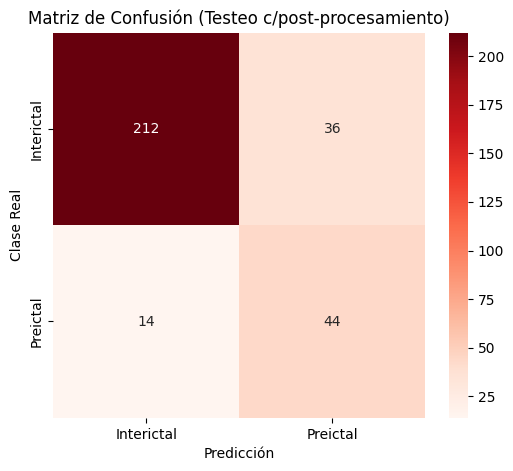


Registro PN00-1.edf: Tiempo de predicción = 225.00 s


EVALUACIÓN DEL MODELO RANDOM FOREST (Testeo c/post-procesamiento):

Precisión (Accuracy): 0.8366
Precisión Positiva (Precision): 0.5500
Sensibilidad (Recall): 0.7586
Puntaje F1: 0.6377

Reporte de Clasificación (Testeo c/post-procesamiento):

              precision    recall  f1-score   support

  Interictal       0.94      0.85      0.89       248
    Preictal       0.55      0.76      0.64        58

    accuracy                           0.84       306
   macro avg       0.74      0.81      0.77       306
weighted avg       0.86      0.84      0.85       306


G-mean: 0.8067296996662958


In [ ]:
for i in range(len(features_05[f"PN{XX}"])): #para cada registro de testeo
  V_pos=0
  F_pos=0
  F_neg=0
  V_neg=0

  cont=0
  cont_2=0
  cont_3=0
  cont_4=0
  for j, etiqueta in enumerate(y_05_pred): #para cada ventana
    desplazamiento=N*(1-overlap/duracion) #desplazamiento por ventana
    inicio_aux=j*desplazamiento #punto de inicio de la ventana
    final_aux=inicio_aux+N-1 #punto final de la ventana
    t_inicio=inicio_aux/fs
    t_final=final_aux/fs
    positivos_reales=math.ceil(300/((final_aux-inicio_aux-1)/fs))

    if etiqueta==1 and inicio_aux>inicio_05*fs-300*fs and final_aux<inicio_05*fs and cont==0:
      t_pred=inicio_05-t_inicio
      cont+=1
    elif etiqueta==1 and inicio_aux>inicio_05*fs-300*fs and final_aux<inicio_05*fs and cont>0:
      cont+=1 #positivos reales
    elif etiqueta==1 and (inicio_aux<inicio_05*fs-300*fs or final_aux>inicio_05*fs):
      cont_2+=1 #falso positivo
    elif etiqueta==0 and inicio_aux>inicio_05*fs-300*fs and final_aux<inicio_05*fs:
      cont_3+=1 #falso negativo
    else:
      cont_4+=1 #negativos reales

  V_pos+=cont
  F_pos+=cont_2
  F_neg+=cont_3
  V_neg+=features_05[f"PN{XX}"][i][2]-cont-cont_2-cont_3

  #listas de valores reales y predichos
  y_true_global=[1]*V_pos+[0]*V_neg+[1]*F_neg+[0]*F_pos
  y_pred_global=[1]*V_pos+[0]*V_neg+[0]*F_neg+[1]*F_pos

  #matriz de confusión
  matriz_confusion=confusion_matrix(y_true_global,y_pred_global)
  plt.figure(figsize=(6,5))
  sns.heatmap(matriz_confusion,annot=True,fmt='d',cmap='Reds',xticklabels=["Interictal","Preictal"],yticklabels=["Interictal","Preictal"])
  plt.xlabel("Predicción")
  plt.ylabel("Clase Real")
  plt.title("Matriz de Confusión (Testeo c/post-procesamiento)")
  plt.show()

#métricas de desempeño globales
accuracy=accuracy_score(y_true_global,y_pred_global)
precision=precision_score(y_true_global,y_pred_global)
recall=recall_score(y_true_global,y_pred_global)
f1=f1_score(y_true_global,y_pred_global)
gmean=geometric_mean_score(y_true_global,y_pred_global,average='macro')

#Reporte de clasificación global
print(f"\nRegistro {features_05[f'PN{XX}'][i][1]}: Tiempo de predicción = {t_pred:.2f} s\n")
print("\nEVALUACIÓN DEL MODELO RANDOM FOREST (Testeo c/post-procesamiento):\n")
print(f"Precisión (Accuracy): {accuracy:.4f}")
print(f"Precisión Positiva (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"Puntaje F1: {f1:.4f}")

print("\nReporte de Clasificación (Testeo c/post-procesamiento):\n")
print(classification_report(y_true_global,y_pred_global,target_names=["Interictal","Preictal"]))
print("\nG-mean:",gmean)


####Modelo SUPPORT VECTOR MACHINE

#####Entrenamiento y validación

Se implementó un modelo Support Vector Machine (SVM) utilizando la función GridSearchCV() de scikit-learn. Esta función permite, para un dado conjunto de datos de entrenamiento, encontrar la configuración de SVM que arroje mejores resultados al ser entrenada con los conjuntos globales X_train e y_train. De esta forma, los datos utilizados con los registros de entrenamiento de **cada paciente** darán una configuración de SVM particular.

La validación se realizó sobre el conjunto de testeo global (X_test) aplicando normalización de características con StandardScaler() y codificación de etiquetas con LabelEncoder().

El modelo fue ajustado con grid_search.fit(X_train,y_train), y posteriormente evaluado con sobre el conjunto de testeo global X_test con modelo_svm.predict(X_test). Para cada muestra, se generaron predicciones y se compararon con las etiquetas reales para obtener métricas de desempeño.


Mejor configuración: {'C': 0.1, 'degree': 3, 'gamma': 0.1, 'kernel': 'poly'}


EVALUACIÓN DE DESEMPEÑO MODELO SUPPORT VECTOR MACHINE:

              precision    recall  f1-score   support

           0       0.83      0.92      0.87        48
           1       0.90      0.81      0.85        47

    accuracy                           0.86        95
   macro avg       0.87      0.86      0.86        95
weighted avg       0.87      0.86      0.86        95


G-mean: 0.8626

Matriz de confusión:



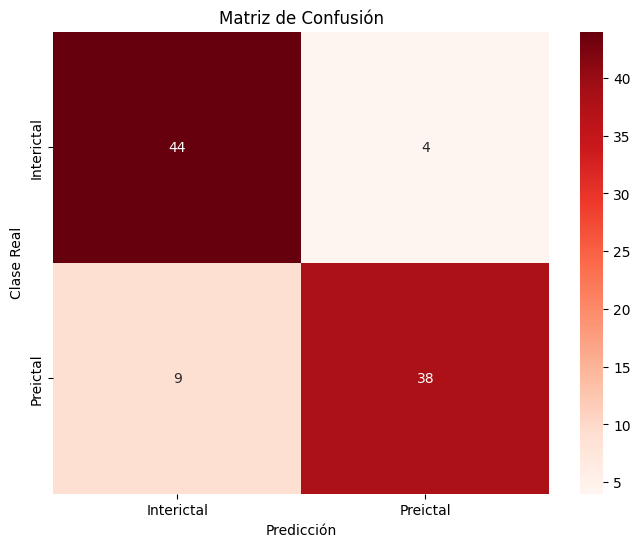


Curva ROC: 



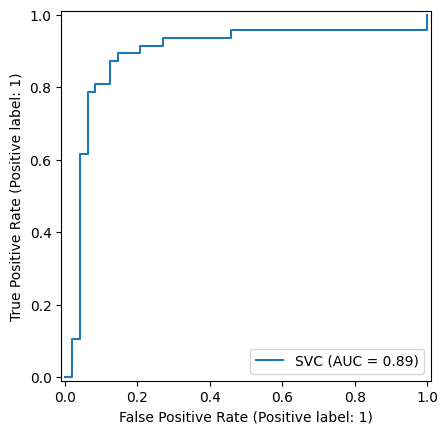

In [ ]:
#Entrenamiento del modelo SUPPORT VECTOR MACHINE
#busca el mejor modelo de SVM
parametros={"kernel":["linear","poly","rbf","sigmoid"],"C":[0.1,1,10],"gamma":["scale","auto",0.1,1],"degree":[2,3,4]}
grid_search=GridSearchCV(SVC(),parametros,cv=5)
grid_search.fit(X_train,y_train)
print(f"\nMejor configuración: {grid_search.best_params_}\n")

#crea el mejor modelo ya entrenado con grid_search
modelo_svm=grid_search.best_estimator_

#TESTEO
y_pred=modelo_svm.predict(X_test) #predicción con el modelo ya entrenado
nombres_target=[str(label) for label in le.classes_]
nombres_clases=["Interictal","Preictal"] #definición de las clases a etiquetar [0,1]

#métricas de performance
print("\nEVALUACIÓN DE DESEMPEÑO MODELO SUPPORT VECTOR MACHINE:\n")
print(classification_report(y_test,y_pred,target_names=nombres_target))

#G-mean
gmean = geometric_mean_score(y_test,y_pred,average='macro')
print(f"\nG-mean: {gmean:.4f}")

#matriz de confusión
matriz=confusion_matrix(y_test,y_pred)
print("\nMatriz de confusión:\n")
plt.figure(figsize=(8,6))
sns.heatmap(matriz,annot=True,fmt='d',cmap='Reds',xticklabels=nombres_clases,yticklabels=nombres_clases)
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Clase Real")
plt.show()

#CURVA ROC
print("\nCurva ROC: \n")
metrics.RocCurveDisplay.from_estimator(modelo_svm,X_test,y_test)
plt.show()

#####Evaluación del modelo

Para verificar la capacidad del modelo en la predicción de eventos preictales, se prueba el modelo entrenado con registros de un paciente, con un registro no etiquetado del mismo paciente.

El modelo generó predicciones sobre este nuevo registro y se compararon con las etiquetas* reales (1 para aquellas ventanas cuyo inicio y fin pertenezca al intervalo de predicción, 0 para el resto) para medir la precisión del sistema. Se analizaron métricas como la tasa de falsos positivos y falsos negativos, evaluando cuán confiable es el modelo para identificar correctamente los eventos preictales.

De acuerdo a lo desarrollado por Detti, el tal; (2017), si un clasificador aplicado sobre un *dataset* sin etiquetar clasifica correctamente al menos una ventana dentro del intervalo de predicción, se considera que la crisis fue predicha correctamente. Por otro lado, si se etiqueta como 1 a una ventana por fuera del intervalo de predicción, la misma debe ser considerada como un falso positivo. Los falsos negativos corresponderán a aquellas ventanas situadas dentro del intervalo de predicción cuya etiqueta asignada sea 0.


*Nota: estas etiquetas fueron computadas manualmente. El registro de testeo únicamente presenta features. Las etiquetas son asignadas luego de realizada la predicción, utilizando la definición de período preictal y los tiempos de inicio/final de crisis calculados en el preprocesamiento.

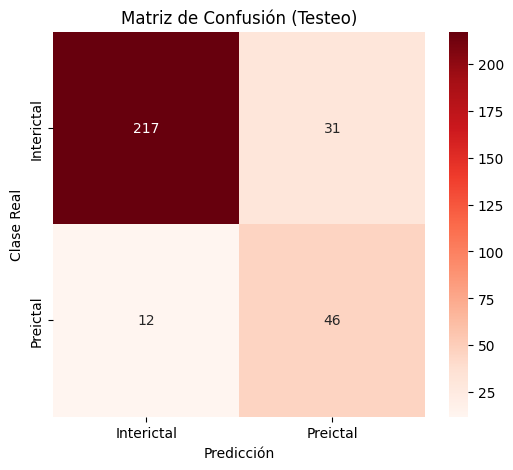


Registro PN00-1.edf: Tiempo de predicción = 265.00 s


EVALUACIÓN DEL MODELO SVM (Testeo):

Precisión (Accuracy): 0.8595
Precisión Positiva (Precision): 0.5974
Sensibilidad (Recall): 0.7931
Puntaje F1: 0.6815

Reporte de Clasificación (Testeo):

              precision    recall  f1-score   support

  Interictal       0.95      0.88      0.91       248
    Preictal       0.60      0.79      0.68        58

    accuracy                           0.86       306
   macro avg       0.77      0.83      0.80       306
weighted avg       0.88      0.86      0.87       306


G-mean: 0.834051724137931


In [ ]:
features_05=features_testeo

#creamos los contadores globales
V_pos=0
F_pos=0
F_neg=0
V_neg=0

for i in range(len(features_05[f"PN{XX}"])): #para cada registro de testeo
  inicio_05=Corte
  final_05=Corte+final[i+len(train)]-inicio[i+len(train)]
  X_05=np.vstack([features_05[f"PN{XX}"][i][0]])
  X_05_esc=scaler.transform(X_05)

  #predicción de clases
  y_05_pred=modelo_svm.predict(X_05_esc)

  cont=0
  cont_2=0
  cont_3=0
  cont_4=0
  for j, etiqueta in enumerate(y_05_pred):
    desplazamiento=N*(1-overlap/duracion) #desplazamiento por ventana
    inicio_aux=j*desplazamiento #punto de inicio de la ventana
    final_aux=inicio_aux+N-1 #punto final de la ventana
    t_inicio=inicio_aux/fs
    t_final=final_aux/fs
    positivos_reales=math.ceil(300/((final_aux-inicio_aux-1)/fs))

    if etiqueta==1 and inicio_aux>inicio_05*fs-300*fs and final_aux<inicio_05*fs and cont==0:
      t_pred=inicio_05-t_inicio
      cont+=1
    elif etiqueta==1 and inicio_aux>inicio_05*fs-300*fs and final_aux<inicio_05*fs and cont>0:
      cont+=1 #positivos reales
    elif etiqueta==1 and (inicio_aux<inicio_05*fs-300*fs or final_aux>inicio_05*fs):
      cont_2+=1 #falso positivo
    elif etiqueta==0 and inicio_aux>inicio_05*fs-300*fs and final_aux<inicio_05*fs:
      cont_3+=1 #falso negativo
    else:
      cont_4+=1 #negativos reales

  V_pos+=cont
  F_pos+=cont_2
  F_neg+=cont_3
  V_neg+=features_05[f"PN{XX}"][i][2]-cont-cont_2-cont_3 #o lo que es lo mismo, cont_4

#listas de valores reales y predichos
y_true_global=[1]*V_pos+[0]*V_neg+[1]*F_neg+[0]*F_pos
y_pred_global=[1]*V_pos+[0]*V_neg+[0]*F_neg+[1]*F_pos

#matriz de confusión
matriz_confusion = confusion_matrix(y_true_global, y_pred_global)
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_confusion,annot=True,fmt='d',cmap='Reds',xticklabels=["Interictal","Preictal"],yticklabels=["Interictal","Preictal"])
plt.xlabel("Predicción")
plt.ylabel("Clase Real")
plt.title("Matriz de Confusión (Testeo)")
plt.show()

#métricas de desempeño globales
accuracy = accuracy_score(y_true_global, y_pred_global)
precision = precision_score(y_true_global, y_pred_global)
recall = recall_score(y_true_global, y_pred_global)
f1 = f1_score(y_true_global, y_pred_global)

#reporte de clasificación global
print(f"\nRegistro {features_05[f'PN{XX}'][i][1]}: Tiempo de predicción = {t_pred:.2f} s\n")
print("\nEVALUACIÓN DEL MODELO SVM (Testeo):\n")
print(f"Precisión (Accuracy): {accuracy:.4f}")
print(f"Precisión Positiva (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"Puntaje F1: {f1:.4f}")
gmean=geometric_mean_score(y_true_global,y_pred_global,average='macro')

print("\nReporte de Clasificación (Testeo):\n")
print(classification_report(y_true_global, y_pred_global,target_names=["Interictal", "Preictal"]))
print("\nG-mean:",gmean)



#####Postprocesamiento

El postprocesamiento realizado a los resultados obtenidos con el modelo de SVM fue esencialmente el mismo que el realizado sobre los resultados de Random Forest. Sin embargo, en este caso el kernel toma valores de longitud entre 2 y 6 muestras incrementadas con paso de 1. Este rango de longitudes, combinadas con los umbrales de 40% de 0s y 50% de 1s ha demostrado dar los mejores resultados.

In [ ]:
#POSTPROCESAMIENTO
for i in range(len(features_05[f"PN{XX}"])): #para cada registro de testeo
  k=2
  while k<=6: #mientras la longitud de la mascara sea menor a 6
    cont=0 #determina el inicio de la mascara
    desplazamiento=k #desplazamiento de la mascara
    while desplazamiento*cont in range(len(y_05_pred)-k): #mientras la mascara esté dentro del rango de etiquetas
      mascara_inicio=desplazamiento*cont #punto de inicio de la mascara
      mascara_final=mascara_inicio+k-1 #punto final de la mascara
      lista=[]
      for m in range(mascara_inicio,mascara_final+1): #se cargan las etiquetas que vio la mascara en una lista auxiliar
        lista.append(y_05_pred[m])
      cont+=1 #actualiza para cambiar el inicio de la mascara
      for posicion in range(len(lista)):
        if lista[posicion]==0 and np.sum(lista)<0.4*k: #si más de 40% de la máscara es 0
          y_05_pred[mascara_inicio:mascara_final]=0
          break
        elif lista[posicion]==1 and np.sum(lista)>0.5*k: #si más del 50% de la máscara es 1
          y_05_pred[mascara_inicio:mascara_final]=1
          break
    k+=1


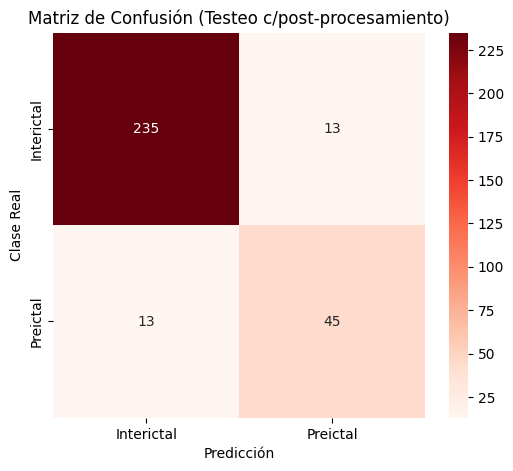


Registro PN00-1.edf: Tiempo de predicción = 270.00 s


EVALUACIÓN DEL MODELO SUPPORT VECTOR MACHINE(Testeo c/post-procesamiento):

Precisión (Accuracy): 0.9150
Precisión Positiva (Precision): 0.7759
Sensibilidad (Recall): 0.7759
Puntaje F1: 0.7759

Reporte de Clasificación (Testeo c/post-procesamiento):

              precision    recall  f1-score   support

  Interictal       0.95      0.95      0.95       248
    Preictal       0.78      0.78      0.78        58

    accuracy                           0.92       306
   macro avg       0.86      0.86      0.86       306
weighted avg       0.92      0.92      0.92       306


G-mean: 0.8617213570634038


In [ ]:
for i in range(len(features_05[f"PN{XX}"])): #para cada registro de testeo
  V_pos=0
  F_pos=0
  F_neg=0
  V_neg=0

  cont=0
  cont_2=0
  cont_3=0
  cont_4=0
  for j, etiqueta in enumerate(y_05_pred): #para cada ventana
    desplazamiento=N*(1-overlap/duracion) #desplazamiento por ventana
    inicio_aux=j*desplazamiento #punto de inicio de la ventana
    final_aux=inicio_aux+N-1 #punto final de la ventana
    t_inicio=inicio_aux/fs
    t_final=final_aux/fs
    positivos_reales=math.ceil(300/((final_aux-inicio_aux-1)/fs))

    if etiqueta==1 and inicio_aux>inicio_05*fs-300*fs and final_aux<inicio_05*fs and cont==0:
      t_pred=inicio_05-t_inicio
      cont+=1
    elif etiqueta==1 and inicio_aux>inicio_05*fs-300*fs and final_aux<inicio_05*fs and cont>0:
      cont+=1 #positivos reales
    elif etiqueta==1 and (inicio_aux<inicio_05*fs-300*fs or final_aux>inicio_05*fs):
      cont_2+=1 #falso positivo
    elif etiqueta==0 and inicio_aux>inicio_05*fs-300*fs and final_aux<inicio_05*fs:
      cont_3+=1 #falso negativo
    else:
      cont_4+=1 #negativos reales

  V_pos+=cont
  F_pos+=cont_2
  F_neg+=cont_3
  V_neg+=features_05[f"PN{XX}"][i][2]-cont-cont_2-cont_3

  #listas de valores reales y predichos
  y_true_global=[1]*V_pos+[0]*V_neg+[1]*F_neg+[0]*F_pos
  y_pred_global=[1]*V_pos+[0]*V_neg+[0]*F_neg+[1]*F_pos

  #matriz de confusión
  matriz_confusion=confusion_matrix(y_true_global,y_pred_global)
  plt.figure(figsize=(6,5))
  sns.heatmap(matriz_confusion,annot=True,fmt='d',cmap='Reds',xticklabels=["Interictal","Preictal"],yticklabels=["Interictal","Preictal"])
  plt.xlabel("Predicción")
  plt.ylabel("Clase Real")
  plt.title("Matriz de Confusión (Testeo c/post-procesamiento)")
  plt.show()

#métricas de desempeño globales
accuracy=accuracy_score(y_true_global,y_pred_global)
precision=precision_score(y_true_global,y_pred_global)
recall=recall_score(y_true_global,y_pred_global)
f1=f1_score(y_true_global,y_pred_global)
gmean=geometric_mean_score(y_true_global,y_pred_global,average='macro')

#Reporte de clasificación global
print(f"\nRegistro {features_05[f'PN{XX}'][i][1]}: Tiempo de predicción = {t_pred:.2f} s\n")
print("\nEVALUACIÓN DEL MODELO SUPPORT VECTOR MACHINE(Testeo c/post-procesamiento):\n")
print(f"Precisión (Accuracy): {accuracy:.4f}")
print(f"Precisión Positiva (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"Puntaje F1: {f1:.4f}")

print("\nReporte de Clasificación (Testeo c/post-procesamiento):\n")
print(classification_report(y_true_global,y_pred_global,target_names=["Interictal","Preictal"]))
print("\nG-mean:",gmean)


##Resultados Machine Learning (todos los pacientes)

El siguiente link deriva a una carpeta de Google Drive con los resultados de este informe extendidos a cada uno de los cinco pacientes utilizados.

Cada subcarpeta PNXX (donde XX es el número de paciente) contiene los resultados (matrices de confusión y métricas) de los clasificadores Random Forest y Support Vector Machine aplicados a los registros (entrenamiento y testeo) de los distintos pacientes (0, 3, 5, 16 y 17).

**Link:** https://drive.google.com/drive/folders/16Na9gKMRwER89NCAl2iGwabJS8qoMM_L?usp=sharing

#DISCUSIÓN Y CONCLUSIONES

Luego de haber preprocesado las señales de dos canales de EEG mediante filtros FIR pasabandas, filtros derivativos, el cálculo de fase a través de la transformada de Hilbert y ventaneo, se logró obtener índices de sincronización de fase PLI y WPLI con curvas que se corresponden a las presentadas por Detti, et al (2019). Habiendo asegurado de esta forma el correcto cómputo de estos de *features*, se procedió al cálculo del MAACD. Este nuevo indicador, cuando utilizado como input de algoritmos de clasificación, permite caracterizar las tendencias en la sincronización de fases.

Posteriormente, se realizó un nuevo preprocesamiento sobre las señales crudas originales, consistente en reorganización de tiempos y filtrado con FIR pasabandas y un filtro notch, con el fin de extraer nuevos *features* estadísticos, tanto temporales como frecuenciales. Estas nuevas características, junto con los features de PLI, WPLI y sus correspondientes MAACD fueron utilizados como input para los clasificadores Random Forest (RF) y Support Vector Machine (SVM). Ambos modelos de aprendizaje supervisado han demostrado tener un buen desempeño en el procesamiento de los datos de los cinco pacientes (0, 3, 5, 16 y 17). A continuación, se proporciona un análisis más detallado de los resultados.

Los registros correspondientes a cada paciente (obtenidos de la base de datos *Siena Scalp Database*) fueron divididos en registros de entrenamiento y un registro de testeo previo a la extracción de características. Los mismos 76 *features* fueron extraídos de ambos tipos de registros, y a los registros de entrenamiento se les asignó adicionalmente una etiqueta (0=interictal, 1=preictal) para cada ventana de 6 segundos. De esta forma, las características de los registros de entrenamiento, junto con sus etiquetas, pudieron ser unificadas correctamente en un único array, logrando un entrenamiento altamente eficiente para ambos modelos. Adicionalmente, la aplicación de técnicas de PCA sobre el total de las características permitió eliminar las redundancias estadísticas de las mismas, agilizando el proceso de clasificación.

De las métricas obtenidas del entrenamiento se observó que los modelos fueron ajustados correctamente, ya que el AUC-ROC y la G-mean fueron cercanos a 1 en todos los casos. La precisión y sensibilidad, por otro lado, si bien obtuvieron valores aceptables, presentaron variaciones notorias entre pacientes, posiblemente asociadas a la diversidad (tanto inter-paciente como intra-paciente) en la morfología de las curvas de índices de sincronización. Aún así, ambos clasificadores demostraron un buen desempeño: en el paciente con mejor rendimiento (paciente 16), el entrenamiento del modelo SVM presentó una G-mean de 0.91 y el de RF una G-mean de 1; mientras que para el paciente con menor rendimiento (paciente 5) las G-mean obtenidas para SVM y RF fueron de 0.541 y 0.708, respectivamente.

Al testear ambos modelos utilizando como input los datos del registro de testeo, es decir, datos no etiquetados, el principal problema que impedía una correcta clasificación fue la longitud de los períodos ictales y preictales. Al haber alrededor de 4 veces más ventanas correspondientes a períodos ictales/postictales/interictales (el etiquetado discrimina), que a períodos preictales, los falsos positivos resultaron ser altos para la mayoría de los pacientes. Para atenuar este fenómeno se realizó un postprocesamiento de las predicciones. Éste consistió en el truncado de los resultados utilizando un kernel incremental e iterativo para la localización de etiquetas aisladas o azarosas, y su conversión a su etiqueta más probable. El postprocesamiento propuesto en este trabajo demostró ser eficiente tanto para el aumento de la precisión como de la sensibilidad de los períodos preictales. Las mejoras más acentuadas en las métricas G-mean, precisión y sensibilidad luego de aplicado el postprocesamiento fueron de 9.5%, 18% y 19% para el modelo SVM y de 2.5%, 10% y 4%, respectivamente.

El algoritmo de clasificación que mejor rendimiento presentó antes y luego del postprocesamiento varía de acuerdo al paciente. Aún así, ambos modelos presentaron un buen desempeño al ser testeados con el registro sin etiquetar (registro de testeo). En el paciente con mejor rendimiento, los G-mean obtenidos con SVM y Random Forest fueron de 0.915 y 0.928, respectivamente, pudiendo incrementarse a 0.93 y 0.941 luego de aplicado el postprocesamiento. Por otro lado, el testeo en el paciente con peor rendimiento dió como resultado una G-mean de 0.62 y 0.7 para SVM y Random Forest, respectivamente, métrica aumentada a 0.715 y 0.712 luego del postprocesamiento. Por otro lado, el tiempo de predicción se mantuvo igual en el 60% de los casos, aumentó en el 20% de los casos y disminuyó en el 20% restante, dejando aún un margen de 180 segundos respecto al inicio de la crisis. Al igual que en el entrenamiento, la precisión y sensibilidad obtenidas en el testeo, tanto antes como después del postprocesamiento, presentaron variaciones entre pacientes, posiblemente debidas a la variabilidad inter-paciente e intra-paciente de las señales analizadas.

En conclusión, los algoritmos de preprocesamiento, procesamiento avanzado y *machine learning* aplicados a lo largo del trabajo presentaron un buen desempeño general, con métricas que reflejan una precisión y sensibilidad variables entre pacientes, y mejorables a través de una etapa de postprocesamiento. Esta variabilidad posiblemente sea ocasionada por la variabilidad en la morfología de las señales de cada paciente. Por último, es importante mencionar que, si bien se consideró el par de canales especificado por Detti, et al (2019) que mejor resalta el período preictal para cada paciente, el mismo no fue especificado para todos los registros de los pacientes. Si bien el presente trabajo generalizó este par de canales para todos los registros del mismo paciente y los resultados obtenidos fueron buenos, es posible que la utilización de pares de canales específicos para cada registro mejore aún más el rendimiento del algoritmo propuesto. Resta probar el desempeño del algoritmo en registros de pacientes con convulsiones distintas a IAS *(focal onset impaired awareness)* en el lóbulo temporal.  

# Bibliografía

1. Shriram, R., Sundhararajan, M., & Daimiwal, N. (2012). *EEG Based Cognitive Workload Assessment for Maximum Efficiency.* IOSR Journal of Electronics and Communication Engineering (IOSR-JECE).

2. Organización Mundial de la Salud (OMS), Revista Médica Clínica Las Condes, Neurología Argentina y PAHO.

3. World Health Organization (WHO). *Epilepsy Fact Sheet.* Recuperado de: [https://www.who.int/es/news-room/fact-sheets/detail/epilepsy](https://www.who.int/es/news-room/fact-sheets/detail/epilepsy).

4. Carolina, P. J., & William, B. B. (2013). *Neuropsicología en epilepsia.* Revista Médica Clínica Las Condes, 24(6), 987–994. [https://doi.org/10.1016/S0716-8640(13)70253-0](https://doi.org/10.1016/S0716-8640(13)70253-0).

5. San-Juan, D., & Rodríguez-Méndez, D. A. (2020). *Epilepsia como una enfermedad de redes neuronales. Un punto de vista neurofisiológico.* Neurología. [https://doi.org/10.1016/j.nrl.2020.06.010](https://doi.org/10.1016/j.nrl.2020.06.010).

6. Fan, M., & Chou, C.-A. (2018). *Detecting Abnormal Pattern of Epileptic Seizures via Temporal Synchronization of EEG Signals.* IEEE Transactions on Biomedical Engineering. [https://doi.org/10.1109/TBME.2018.2850959](https://doi.org/10.1109/TBME.2018.2850959).

7. Detti, P., Vatti, G., & Zabalo Manrique de Lara, G. (2017). *EEG Synchronization Analysis for Seizure Prediction: A Study on Data of Noninvasive Recordings.* Biomedical Signal Processing and Control. [https://doi.org/10.1016/j.bspc.2017.02.001](https://doi.org/10.1016/j.bspc.2017.02.001).

8. Detti, P., de Lara, G. Z. M., Bruni, R., Pranzo, M., Sarnari, F., & Vatti, G. (2019). *A Patient-Specific Approach for Short-Term Epileptic Seizures Prediction Through the Analysis of EEG Synchronization.* IEEE Transactions on Biomedical Engineering, 66(6), 1494-1504. [https://doi.org/10.1109/TBME.2018.2874716](https://doi.org/10.1109/TBME.2018.2874716).

9. Majumdar, K. K., & Vardhan, P. (2011). Automatic Seizure Detection in ECoG by Differential Operator and Windowed Variance. IEEE Transactions on Neural Systems and Rehabilitation Engineering, 19(4), 356–365. doi:10.1109/tnsre.2011.2157525